<a href="https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/T004_nsclc_llm_coscientist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Co-scientist 로 폐동맥고혈압(PAH) 표적 후보 평가하기

**Day 06 · LLM 에이전트 실습**

PubMed 실검색과 Gemini 기반 멀티에이전트(LangChain + LangGraph)를 엮어 PAH 표적 후보 유전자 14개를
자동으로 조사·평가·순위화한다. API 키가 없어도 실데이터 구간(문헌 계량·대진표 구조)은 끝까지 실행된다.


## 0. 실행 환경

- **GPU 불필요.** 추론은 Google Gemini API 서버에서 수행됩니다.
- **Google Gemini API 키가 필요합니다** — https://aistudio.google.com/app/apikey 에서 무료 발급.
  Colab 이면 왼쪽 🔑(보안 비밀) 아이콘에 이름 `GOOGLE_API_KEY` 로 저장하고 이 노트북의
  액세스를 켜세요. 없으면 환경변수 → `getpass` 순으로 찾습니다.
  **키는 어느 경로로 넣든 노트북 파일에 저장되지 않습니다.**
  키가 없어도 노트북은 끝까지 실행됩니다 — LLM 구간만 건너뛰고 그 구간의 점수는 비워 둡니다.
- **네트워크**: NCBI PubMed E-utilities(문헌 검색)와 Google API 두 곳에 접속합니다.
- 유전자 14개 × 5 에이전트 = 약 70회 LLM 호출입니다. 무료 티어 rate limit에 걸리면
  4절의 `TARGET_GENES` 를 3~4개로 줄여서 실행하세요.
- 아래 셀이 필요한 패키지를 먼저 확인해 **없는 것만** 설치하고, 연산 장치를 `DEVICE` 상수 하나로 고정합니다.


In [1]:
import importlib, subprocess, sys

REQUIRED = {
    # "import 이름": "pip 패키지명"
    "langchain_core": "langchain",                      # PromptTemplate
    "langchain_google_genai": "langchain-google-genai",  # Gemini 챗 모델 래퍼
    "langgraph": "langgraph",                            # 멀티에이전트 상태 그래프
    "google.genai": "google-genai",                      # 사용 가능 모델 조회 (구 google-generativeai 대체)
    "seaborn": "seaborn",                                # 그림 스타일
    "plotly": "plotly",                                  # 인터랙티브 시각화
    "wordcloud": "wordcloud",                            # 키워드 워드클라우드
    "networkx": "networkx",                              # 유전자 공동 출현 네트워크
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


# 이 노트북은 로컬 GPU 연산을 하지 않는다 (추론은 Gemini API 서버에서 수행).
# 그래도 다른 실습과 형식을 맞추기 위해 연산 장치 상수를 정의해 둔다.
print("Python:", sys.version.split()[0])
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("PyTorch:", torch.__version__)
    if DEVICE == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))
except ImportError:
    DEVICE = "cpu"
    print("PyTorch 미설치 (이 노트북에는 필요 없습니다)")
print("DEVICE =", DEVICE, "(로컬 연산 없음 — 표기용)")
print("[안내] 필요한 것은 Google Gemini API 키뿐입니다: https://aistudio.google.com/app/apikey")


모든 의존 패키지가 이미 준비되어 있습니다.
Python: 3.12.3


PyTorch: 2.14.0+cpu
DEVICE = cpu (로컬 연산 없음 — 표기용)
[안내] 필요한 것은 Google Gemini API 키뿐입니다: https://aistudio.google.com/app/apikey


## 1. 개요와 학습 목표

- **무엇을 만드나** — 문헌 검색 → 기전 분석 → 임상 관련성 → 약물화 가능성 → 종합 판정의
  다섯 역할을 각각 LLM 에이전트로 세우고, LangGraph 상태 그래프로 이어 붙인다.
- **무엇을 평가하나** — 폐동맥고혈압(PAH) 표적 후보 유전자 14개를 점수화하고 토너먼트로 순위를 매긴다.
- **실데이터는 어디까지인가** — 문헌 히트 수·발행연도·초록은 NCBI E-utilities 로 **실제 조회**한 값이다.
  LLM 점수는 모델의 판단이며 실험 근거가 아니다. 키가 없으면 그 칸은 비워 두고 지어내지 않는다.
- **배우는 것** — LangChain 1.x 파이프(`prompt | llm`) 사용법, LangGraph 상태/노드 구성,
  PubMed API 자동화, 쌍별 비교 기반 순위 결정, 그리고 "근거 없는 칸은 비워 둔다"는 보고 원칙.

### 1-1. 이 튜토리얼의 목표

본 튜토리얼은 LLM(Large Language Model) 기반 Co-scientist 시스템을 구축하여 폐동맥고혈압(PAH) 표적 후보
유전자들에 대한 자동화된 논문 검색, 분석, 평가를 수행합니다. 멀티에이전트 시스템을 통해 각 유전자의
치료 표적으로서의 가능성을 종합적으로 평가하고 순위를 매깁니다.

**학습 목표**

1. LangChain과 LangGraph를 활용한 멀티에이전트 시스템 구축
2. Google Gemini API를 통한 LLM 기반 논문 분석
3. PubMed API를 활용한 자동화된 문헌 검색
4. 토너먼트 방식의 표적 후보 평가 시스템
5. 반복적 개선 및 결과 시각화

### 1-2. 이론 배경

#### LLM Co-scientist 개념
- **정의**: 대형 언어 모델을 활용하여 과학적 연구 과정을 자동화하는 AI 시스템
- **구성요소**: 가설 생성, 문헌 검토, 실험 설계, 결과 분석, 결론 도출
- **장점**: 대규모 데이터 처리, 편향 감소, 24/7 연구 수행 가능

#### 멀티에이전트 시스템 아키텍처
- **Literature Agent**: PubMed 검색 및 논문 요약
- **Analysis Agent**: 분자생물학적 메커니즘 분석
- **Clinical Agent**: 임상적 관련성 평가
- **Drug Agent**: 약물 개발 가능성 평가
- **Judge Agent**: 종합 평가 및 순위 결정

#### 표적 평가 기준
- **과학적 근거** (25%): 논문 수, 인용 횟수, 연구 품질
- **임상적 관련성** (25%): 환자 하위군, 예후 예측력
- **약물 개발 가능성** (25%): Druggability, 기존 약물 존재
- **시장성** (25%): 환자 수, 미충족 의료 필요

#### LangGraph 워크플로우
- **상태 관리**: 각 에이전트 간 정보 전달
- **조건부 라우팅**: 평가 결과에 따른 다음 단계 결정
- **반복 개선**: 피드백 루프를 통한 결과 정제

---

### 1-3. 실습 순서


1. **환경 설정 및 API 연결**
   - Google Gemini API 설정
   - LangChain, LangGraph 설치
   - PubMed API 접근
   
2. **멀티에이전트 시스템 구축**
   - 각 전문 에이전트 정의
   - 상태 관리 시스템 구성
   - 워크플로우 설계
   
3. **표적 유전자 평가 파이프라인**
   - 자동 문헌 검색
   - 다각도 분석 수행
   - 점수 산정 및 랭킹
   
4. **토너먼트 평가 시스템**
   - 쌍별 비교 평가
   - 일관성 검증
   - 최종 순위 결정
   
5. **결과 시각화 및 해석**
   - 점수 분포 분석
   - 카테고리별 강점/약점 분석
   - 임상적 함의 도출


## 2. 라이브러리 임포트와 Gemini API 설정

먼저 필요한 패키지들을 설치하고 Google Gemini API를 설정합니다.

In [2]:
# 기본 라이브러리 임포트
# (패키지 설치는 0절 ensure(REQUIRED) 에서 이미 끝났습니다.
#  주의: 예전의 google-generativeai SDK는 폐지되었고 google-genai로 대체되었습니다.
#  langchain-google-genai 가 google-genai 를 의존성으로 함께 설치합니다.)
import os
import re
import json
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
import networkx as nx
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# LangChain 라이브러리
# 주의: LangChain 1.x에서 langchain.prompts / langchain.chains 모듈이 제거되었습니다.
#       PromptTemplate은 langchain_core.prompts 로, LLMChain은 prompt | llm 파이프로 대체됩니다.
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from typing import Dict, List, Any, TypedDict

# Google Gen AI SDK (구 google.generativeai 대체)
from google import genai

# 시각화 설정
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

print("✅ 라이브러리 임포트 완료!")

✅ 라이브러리 임포트 완료!


In [3]:
# Google Gemini API 설정 — 키 발급: https://aistudio.google.com/app/apikey
#
# [권장] Colab 에서는 왼쪽 🔑(보안 비밀) 아이콘 → 이름을 GOOGLE_API_KEY 로 저장하고
#        이 노트북의 "액세스" 를 켜세요. 셀에 키를 붙여넣지 않아도 되고,
#        노트북을 저장하거나 공유해도 키가 함께 나가지 않습니다.
# [중요] 키가 없어도 노트북은 끝까지 실행됩니다 — LLM 구간만 건너뛰고 그 구간의 점수는
#        "미실행(NaN)" 으로 남습니다. 임의의 기본 점수(예: 5.0)로 채우면 그림이 실제
#        평가처럼 보이지만 근거 없는 가짜 수치이므로 그렇게 하지 않습니다.
import logging

# langchain 래퍼가 내부적으로 models.generate_content 를 호출하며 남기는
# AFC(automatic function calling) 권고 경고를 수업 화면에서 줄인다.
logging.getLogger("google_genai.models").setLevel(logging.ERROR)


def get_api_key(name: str = "GOOGLE_API_KEY") -> str | None:
    """API 키를 Colab Secrets → 환경변수 → getpass 순으로 찾는다. 없으면 None."""
    # 1) Colab Secrets (권장): 좌측 🔑 아이콘 → 이름 GOOGLE_API_KEY 로 저장 후 노트북 접근 허용
    try:
        from google.colab import userdata
        key = userdata.get(name)
        if key:
            print(f"[키] Colab Secrets 에서 {name} 를 읽었습니다.")
            return key
    except Exception:
        pass  # Colab 이 아니거나 시크릿 미설정/미허용
    # 2) 환경변수
    key = os.environ.get(name) or os.environ.get("GEMINI_API_KEY")
    if key:
        print(f"[키] 환경변수에서 {name} 를 읽었습니다.")
        return key
    # 3) 대화형 입력 (비대화식 실행에서는 건너뜀 — 자동 실행이 멈추지 않도록)
    try:
        import getpass
        if sys.stdin.isatty():
            entered = getpass.getpass(f"{name} (입력 없이 Enter 시 건너뜀): ").strip()
            if entered:
                return entered
    except Exception:
        pass
    return None


import re   # _gemini_rank 의 버전 파싱용 (셀 단독 실행 대비)

# 폴백 후보 (계정 목록 조회가 막힌 키에서만 쓰인다). 최신 → 구형 순.
# 2026-09 기준 현행 stable 만 남긴다. gemini-1.5 / 2.0-flash 는 서비스 종료,
# "gemini-3-flash" 는 존재하지 않는 이름이라 뺐다.
# 계정 목록을 읽을 수 있으면 이 목록은 쓰이지 않는다 (거기서 최신순으로 고른다).
GEMINI_CANDIDATES = ["gemini-3.8-flash", "gemini-3.7-flash", "gemini-3.6-flash",
                     "gemini-3.5-flash", "gemini-2.5-flash"]

# 이름에 아래 조각이 들어간 모델은 일반 텍스트 대화용이 아니다.
# 실측: gemini-omni-1.1-flash 는 models.list() 에는 뜨지만 호출하면
#   400 INVALID_ARGUMENT "This model only supports Interactions API" 를 돌려준다.
GEMINI_EXCLUDE = ("omni", "image", "tts", "audio", "live", "embedding",
                  "vision-latest", "realtime")


def _gemini_rank(name: str) -> tuple:
    """정렬 키 (클수록 우선): 버전 → 정식출시 → 풀사이즈.

    이름에 박힌 버전을 직접 읽으므로, 앞으로 더 새 모델이 나와도
    코드를 고치지 않고 자동으로 최신을 고른다.
    """
    m = re.search(r"gemini-(\d+)(?:\.(\d+))?", name)
    major, minor = (int(m.group(1)), int(m.group(2) or 0)) if m else (0, 0)
    stable = 0 if any(t in name for t in ("preview", "exp")) else 1
    full = 0 if "lite" in name else 1
    return (major, minor, stable, full)


def list_gemini_models(client) -> list:
    """계정에서 generateContent 를 지원한다고 보고된 모델 이름만 추린다."""
    names = []
    for m in client.models.list():
        actions = list(getattr(m, "supported_actions", None) or [])
        if (not actions) or ("generateContent" in actions):
            names.append(str(m.name).split("/")[-1])
    return names


def gemini_candidate_order(available: list, prefer: list) -> list:
    """계정에 실제로 있는 모델을 최신순으로 세우고, 폴백 후보를 뒤에 붙인다."""
    ok = lambda n: n.startswith("gemini") and not any(b in n for b in GEMINI_EXCLUDE)
    flash = sorted((n for n in available if ok(n) and "flash" in n),
                   key=_gemini_rank, reverse=True)
    other = sorted((n for n in available if ok(n) and "flash" not in n),
                   key=_gemini_rank, reverse=True)
    order = flash + other                      # 무료 티어에선 flash 계열이 먼저
    order += [n for n in prefer if n not in order]
    return order


def resolve_gemini_model(client, prefer: list = GEMINI_CANDIDATES, max_try: int = 5):
    """실제로 응답하는 최신 모델을 고른다. 못 찾으면 None.

    이름만 보고 고르면 안 된다 — 목록에 있어도 텍스트 대화를 지원하지 않는 모델이
    섞여 있고, 은퇴한 모델이 남아 있기도 한다. 그래서 최신순으로 세운 뒤
    1토큰짜리로 한 번 호출해 보고 성공한 첫 모델을 쓴다.
    """
    try:
        available = list_gemini_models(client)
    except Exception as exc:
        print(f"[안내] models.list() 실패({type(exc).__name__}) — 후보를 직접 호출해 확인합니다.")
        available = []
    order = gemini_candidate_order(available, prefer)
    if available:
        print(f"계정에서 호출 가능한 모델 {len(available)}개 → 최신순 시도: {order[:max_try]}")
    for name in order[:max_try]:
        try:
            client.models.generate_content(model=name, contents="ping")
            print(f"선택: {name}")
            return name
        except Exception as exc:
            print(f"  - {name}: 사용 불가 ({type(exc).__name__})")
    return None


def _as_text(resp) -> str:
    """LLM 응답을 언제나 문자열로 만든다.

    langchain 의 AIMessage.content 는 모델에 따라 str 이 아니라 content block
    리스트로 온다 (예: [{"type": "text", "text": "..."}], 앞에 thinking 블록이
    붙기도 한다). 실측: gemini-3.7-flash 가 리스트를 돌려주는 바람에
    judge_agent 의 result.split("\n") 이
    "'list' object has no attribute 'split'" 로 터졌다.
    """
    # 신버전 langchain-core 는 .text 헬퍼를 준다 (버전에 따라 속성/메서드)
    txt = getattr(resp, "text", None)
    if callable(txt):
        try:
            txt = txt()
        except Exception:
            txt = None
    if isinstance(txt, str) and txt.strip():
        return txt

    content = getattr(resp, "content", resp)
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for blk in content:
            if isinstance(blk, str):
                parts.append(blk)
            elif isinstance(blk, dict):
                # 사고 과정(thinking/reasoning) 블록은 본문이 아니므로 제외한다
                if blk.get("type") in (None, "text") and blk.get("text"):
                    parts.append(blk["text"])
        return "\n".join(parts)
    return str(content)


GOOGLE_API_KEY = get_api_key("GOOGLE_API_KEY") or ""
LLM_AVAILABLE = bool(GOOGLE_API_KEY)
LLM_SKIP_REASON = "" if LLM_AVAILABLE else "GOOGLE_API_KEY not set - LLM agent steps skipped"
if LLM_AVAILABLE:
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

LLM_NOT_RUN = "[LLM 미실행] API 키가 없어 이 분석은 수행되지 않았습니다."

if LLM_AVAILABLE:
    try:
        MODEL_NAME = resolve_gemini_model(genai.Client(api_key=GOOGLE_API_KEY))
        if MODEL_NAME is None:
            raise RuntimeError("응답하는 Gemini 모델을 찾지 못했습니다 (키·할당량 확인).")
        llm = ChatGoogleGenerativeAI(model=MODEL_NAME, temperature=0.3)
        test_response = llm.invoke("Hello! Please respond with 'API connection successful'")
        print(f"테스트 응답: {_as_text(test_response)}")
        print("✅ Google Gemini API 연결 완료!")
    except Exception as e:
        LLM_AVAILABLE = False
        LLM_SKIP_REASON = f"Gemini init failed: {type(e).__name__}"
        llm, MODEL_NAME = None, None
        print(f"⚠️ Gemini 초기화 실패: {type(e).__name__}: {e}")
else:
    llm, MODEL_NAME = None, None
    print(f"⚠️ {LLM_SKIP_REASON}")
    print("   -> 4절(PubMed 실데이터 그림)과 9-1절(대진표 구조)은 그대로 실행됩니다.")
    print("   -> LLM 점수가 필요한 그림은 값을 지어내지 않고 비워 둡니다.")


def run_prompt(prompt, **kwargs):
    """LangChain 1.x에서 제거된 LLMChain(llm, prompt).run(**kwargs)의 대체.

    현재 권장 방식은 프롬프트와 모델을 파이프로 연결하는 것입니다:
        chain = prompt | llm
        chain.invoke({...})  ->  AIMessage

    LLM을 쓸 수 없으면 LLM_NOT_RUN 문자열을 그대로 돌려줍니다.
    (가짜 응답을 만들지 않고, 호출한 쪽이 "점수 없음"으로 처리하게 합니다)
    """
    if not LLM_AVAILABLE:
        return LLM_NOT_RUN
    chain = prompt | llm
    # .content 를 그대로 쓰면 안 된다 — 모델에 따라 리스트가 온다 (_as_text 주석 참고)
    return _as_text(chain.invoke(kwargs))


print(f"LLM_AVAILABLE = {LLM_AVAILABLE}")

⚠️ GOOGLE_API_KEY not set - LLM agent steps skipped
   -> 4절(PubMed 실데이터 그림)과 9-1절(대진표 구조)은 그대로 실행됩니다.
   -> LLM 점수가 필요한 그림은 값을 지어내지 않고 비워 둡니다.
LLM_AVAILABLE = False


## 3. PubMed API 및 문헌 검색 시스템 구축

In [4]:
# PubMed API 클래스 (NCBI E-utilities)
#
# [중요] 이전 버전은 efetch 결과를 파싱하지 않고 "Paper {pmid} about ..." 같은
#        가짜 제목/초록을 만들어 LLM에 넣었습니다. 그러면 에이전트가 실제 문헌이
#        아니라 자기가 지어낸 문자열을 근거로 점수를 매기게 됩니다.
#        아래는 efetch XML을 실제로 파싱해 제목/초록/연도/저널을 가져옵니다.
import xml.etree.ElementTree as ET


class PubMedSearcher:
    """NCBI E-utilities 로 PubMed 논문을 검색하고 제목·초록을 실제로 파싱해 오는 검색기."""
    def __init__(self, email="fourmodern@gmail.com"):
        self.base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
        self.email = email  # NCBI 정책상 이메일 필요

    def search_papers(self, query, max_results=20):
        """PubMed에서 논문 PMID 검색"""
        params = {"db": "pubmed", "term": query, "retmax": max_results,
                  "retmode": "json", "email": self.email}
        try:
            response = requests.get(self.base_url + "esearch.fcgi", params=params, timeout=30)
            response.raise_for_status()
            return response.json()["esearchresult"]["idlist"]
        except Exception as e:
            print(f"검색 오류: {e}")
            return []

    @staticmethod
    def _text(node):
        return "".join(node.itertext()).strip() if node is not None else ""

    def get_paper_details(self, pmids):
        """PMID 목록으로 efetch 후 XML을 실제로 파싱"""
        if not pmids:
            return []
        params = {"db": "pubmed", "id": ",".join(pmids), "retmode": "xml", "email": self.email}
        try:
            response = requests.get(self.base_url + "efetch.fcgi", params=params, timeout=60)
            response.raise_for_status()
            root = ET.fromstring(response.text)
        except Exception as e:
            print(f"상세 정보 가져오기 오류: {e}")
            return []

        papers = []
        for art in root.findall(".//PubmedArticle"):
            abstract = " ".join(self._text(n) for n in art.findall(".//Abstract/AbstractText"))
            papers.append({
                "pmid": art.findtext(".//PMID") or "",
                "title": self._text(art.find(".//ArticleTitle")),
                "abstract": abstract,
                "year": (art.findtext(".//JournalIssue/PubDate/Year")
                         or art.findtext(".//JournalIssue/PubDate/MedlineDate") or ""),
                "journal": (art.findtext(".//Journal/ISOAbbreviation")
                            or art.findtext(".//Journal/Title") or ""),
            })
        return papers

    def search_gene_papers(self, gene_name, disease="pulmonary arterial hypertension", max_results=10):
        """특정 유전자와 질환에 대한 논문 검색"""
        query = f"{gene_name} AND {disease} AND (target OR therapy OR mutation)"
        return self.get_paper_details(self.search_papers(query, max_results))


# PubMed 검색기 초기화
pubmed = PubMedSearcher()
print("✅ PubMed 검색기 초기화 완료!")

# 테스트 검색 - 실제 논문 제목이 나와야 정상입니다
test_papers = pubmed.search_gene_papers("PDE5A", max_results=3)
print(f"\n테스트 검색 결과: {len(test_papers)}개 논문 발견")
for paper in test_papers:
    print(f"  - PMID {paper['pmid']} ({paper['year']}, {paper['journal']}): {paper['title'][:70]}...")
if not test_papers:
    print("  [주의] 0건입니다. NCBI 일시 오류이거나 네트워크 차단일 수 있습니다. 잠시 후 다시 실행하세요.")

✅ PubMed 검색기 초기화 완료!



테스트 검색 결과: 3개 논문 발견
  - PMID 42390922 (2026, J Enzyme Inhib Med Chem): Selective targeting phosphodiesterase-5 (PDE5): clinical progress, des...
  - PMID 40880357 (2025, PLoS One): β-aminopropionitrile-induced thoracic aortopathy is refractory to cilo...
  - PMID 39951190 (2025, Mol Neurobiol): Genetically Proxied Phosphodiesterase Type 5 (PDE5) Inhibition and Ris...


## 4. PubMed 실데이터 문헌 계량 (LLM 없이 실행되는 구간)

이어지는 네 개의 그림은 **LLM을 전혀 쓰지 않습니다.** NCBI E-utilities로 실제 검색해 받아온
히트 수와 발행연도만으로 그립니다. 그래서 API 키가 없어도 항상 그림이 나오고,
"에이전트가 무엇을 보고 판단하는가"의 입력 데이터를 눈으로 검증할 수 있습니다.

아래 셀은 후보 유전자 14개에 대해 (1) 전체 히트 수(esearch `count`)와
(2) 최근 논문 최대 1000건의 발행연도(esummary), (3) 에이전트에 넣을 초록 10건(efetch)을 받아옵니다.
NCBI 정책상 API 키 없이 초당 3요청 제한이 있어 요청 사이에 0.5초씩 쉽니다 (총 60초 내외).

**읽을 때 주의**: 검색은 유전자 심볼 기준이라, 심볼 대신 단백질명·약물군으로만 쓰인 논문은
빠집니다 (예: `EDNRA` 대신 "endothelin receptor A"). 히트 수는 **하한**으로 읽어야 하고,
심볼 관행이 다른 유전자끼리의 절대 비교는 조심해야 합니다.

In [5]:
# --- PubMed 문헌 계량 수집 (실제 API 호출, LLM 불필요) ---------------------
import time as _time
from datetime import datetime, timezone

# 평가 대상 폐동맥고혈압(PAH) 표적 후보 유전자 (established PAH 연관 표적; 문헌 확인 권장)
#
# [실습 팁] 7절에서 유전자 1개당 LLM 호출 5회 = 총 70회입니다.
#           Gemini 무료 티어 rate limit에 걸리면 아래 목록을 3~4개로 줄이세요.
#           예: TARGET_GENES = ["PDE5A", "BMPR2", "EDNRA"]
TARGET_GENES = [
    "PDE5A", "GUCY1A1", "GUCY1B1", "EDNRA", "EDNRB", "PTGIR", "NOS3",
    "BMPR2", "ACVRL1", "ENG", "GDF2", "KCNK3", "CAV1", "SMAD9"
]

# 필드 제한 없이 PubMed 자동 용어 매핑(automatic term mapping)에 맡깁니다.
# [Title/Abstract] 로 묶으면 초록에 심볼을 안 쓴 논문이 통째로 빠져 히트 수가 과소집계됩니다.
LIT_QUERY_TMPL = "{gene} AND pulmonary arterial hypertension"
LIT_MAX_FETCH = 1000         # 연도 분석용 표본 상한 (히트 수 자체는 전체 count 사용)
NCBI_PAUSE = 0.5             # NCBI: API 키 없이 초당 3요청 제한
_BASE = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"


def esearch_count_and_ids(query, retmax=LIT_MAX_FETCH):
    """esearch 로 전체 히트 수와 최근 PMID 목록을 함께 얻습니다."""
    r = requests.get(_BASE + "esearch.fcgi", timeout=30, params={
        "db": "pubmed", "term": query, "retmax": retmax,
        "retmode": "json", "sort": "pub_date", "email": pubmed.email})
    r.raise_for_status()
    res = r.json()["esearchresult"]
    return int(res.get("count", 0)), res.get("idlist", [])


def esummary_years(pmids):
    """esummary 로 PMID들의 발행연도를 얻습니다 (파싱 실패 항목은 버립니다)."""
    years = []
    for i in range(0, len(pmids), 200):
        chunk = pmids[i:i + 200]
        r = requests.get(_BASE + "esummary.fcgi", timeout=60, params={
            "db": "pubmed", "id": ",".join(chunk),
            "retmode": "json", "email": pubmed.email})
        r.raise_for_status()
        result = r.json().get("result", {})
        for pmid in chunk:
            rec = result.get(pmid)
            if not isinstance(rec, dict):
                continue
            m = re.match(r"(\d{4})", str(rec.get("pubdate", "")))
            if m:
                years.append((pmid, int(m.group(1))))
        _time.sleep(NCBI_PAUSE)
    return years


LIT_HITS_BY_GENE = {}        # gene -> 전체 히트 수 (실데이터)
LIT_PMIDS_BY_GENE = {}       # gene -> PMID 목록 (최근 LIT_MAX_FETCH 건)
LIT_PAPERS_BY_GENE = {}      # gene -> 초록 dict 목록 (에이전트 입력용)
_year_rows = []

print(f"PubMed 계량 수집 시작 — 유전자 {len(TARGET_GENES)}개 (약 60초)")
for g in TARGET_GENES:
    try:
        n_hits, pmids = esearch_count_and_ids(LIT_QUERY_TMPL.format(gene=g))
    except Exception as e:
        print(f"  ⚠️ {g}: esearch 실패 ({type(e).__name__}) — 0건 처리")
        n_hits, pmids = 0, []
    LIT_HITS_BY_GENE[g] = n_hits
    LIT_PMIDS_BY_GENE[g] = pmids
    _time.sleep(NCBI_PAUSE)

    n_year = 0
    try:
        for pmid, yr in esummary_years(pmids):
            _year_rows.append({"Gene": g, "PMID": pmid, "Year": yr})
            n_year += 1
    except Exception as e:
        print(f"  ⚠️ {g}: esummary 실패 ({type(e).__name__}) — 연도 분석 제외")

    try:
        LIT_PAPERS_BY_GENE[g] = pubmed.get_paper_details(pmids[:10])
    except Exception:
        LIT_PAPERS_BY_GENE[g] = []
    _time.sleep(NCBI_PAUSE)

    print(f"  {g:<8} hits={n_hits:>7,}   연도확보={n_year:>3}   초록={len(LIT_PAPERS_BY_GENE[g]):>2}")

lit_year_df = pd.DataFrame(_year_rows)
LIT_TOTAL_HITS = sum(LIT_HITS_BY_GENE.values())
LIT_FETCH_TS = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
THIS_YEAR = datetime.now(timezone.utc).year

print(f"\n✅ 수집 완료 ({LIT_FETCH_TS})")
print(f"   전체 히트 합계 : {LIT_TOTAL_HITS:,}건")
print(f"   연도 확보 논문 : {len(lit_year_df):,}건")
print(f"   초록 확보      : {sum(len(v) for v in LIT_PAPERS_BY_GENE.values())}건")
if not lit_year_df.empty:
    print(f"   연도 범위      : {lit_year_df['Year'].min()} - {lit_year_df['Year'].max()}")
_capped = [g for g, n in LIT_HITS_BY_GENE.items() if n > LIT_MAX_FETCH]
print(f"   표본 상한({LIT_MAX_FETCH})에 걸린 유전자: {_capped if _capped else '없음'}")
print("   ※ 유전자 심볼 검색이므로, 심볼 대신 단백질/약물군 이름으로만 쓰인 논문은 빠집니다")
print("     (예: EDNRA -> 'endothelin receptor A'). 히트 수는 하한으로 읽으세요.")


PubMed 계량 수집 시작 — 유전자 14개 (약 60초)


  PDE5A    hits=     61   연도확보= 61   초록=10


  GUCY1A1  hits=      1   연도확보=  1   초록= 1


  GUCY1B1  hits=      2   연도확보=  2   초록= 2


  EDNRA    hits=      2   연도확보=  2   초록= 2


...

  ENG      hits=    170   연도확보=170   초록= 9


  GDF2     hits=     52   연도확보= 52   초록= 9


  KCNK3    hits=     79   연도확보= 79   초록= 9


  CAV1     hits=     95   연도확보= 95   초록= 9


  SMAD9    hits=     35   연도확보= 35   초록= 9

✅ 수집 완료 (2026-09-04 08:58 UTC)
   전체 히트 합계 : 1,618건
   연도 확보 논문 : 1,618건
   초록 확보      : 103건
   연도 범위      : 1981 - 2026
   표본 상한(1000)에 걸린 유전자: 없음
   ※ 유전자 심볼 검색이므로, 심볼 대신 단백질/약물군 이름으로만 쓰인 논문은 빠집니다
     (예: EDNRA -> 'endothelin receptor A'). 히트 수는 하한으로 읽으세요.


### 4-1. 유전자별 PubMed 논문 수

각 후보 유전자가 PAH 문헌에서 얼마나 다뤄졌는지를 실제 검색 히트 수로 봅니다.
왼쪽은 로그 스케일 히트 수, 오른쪽은 상위 유전자가 전체 문헌에서 차지하는 누적 비중입니다.
문헌이 많다는 것은 "근거가 두텁다"는 뜻이면서 동시에 "이미 붐비는 영역"이라는 뜻이기도 합니다.

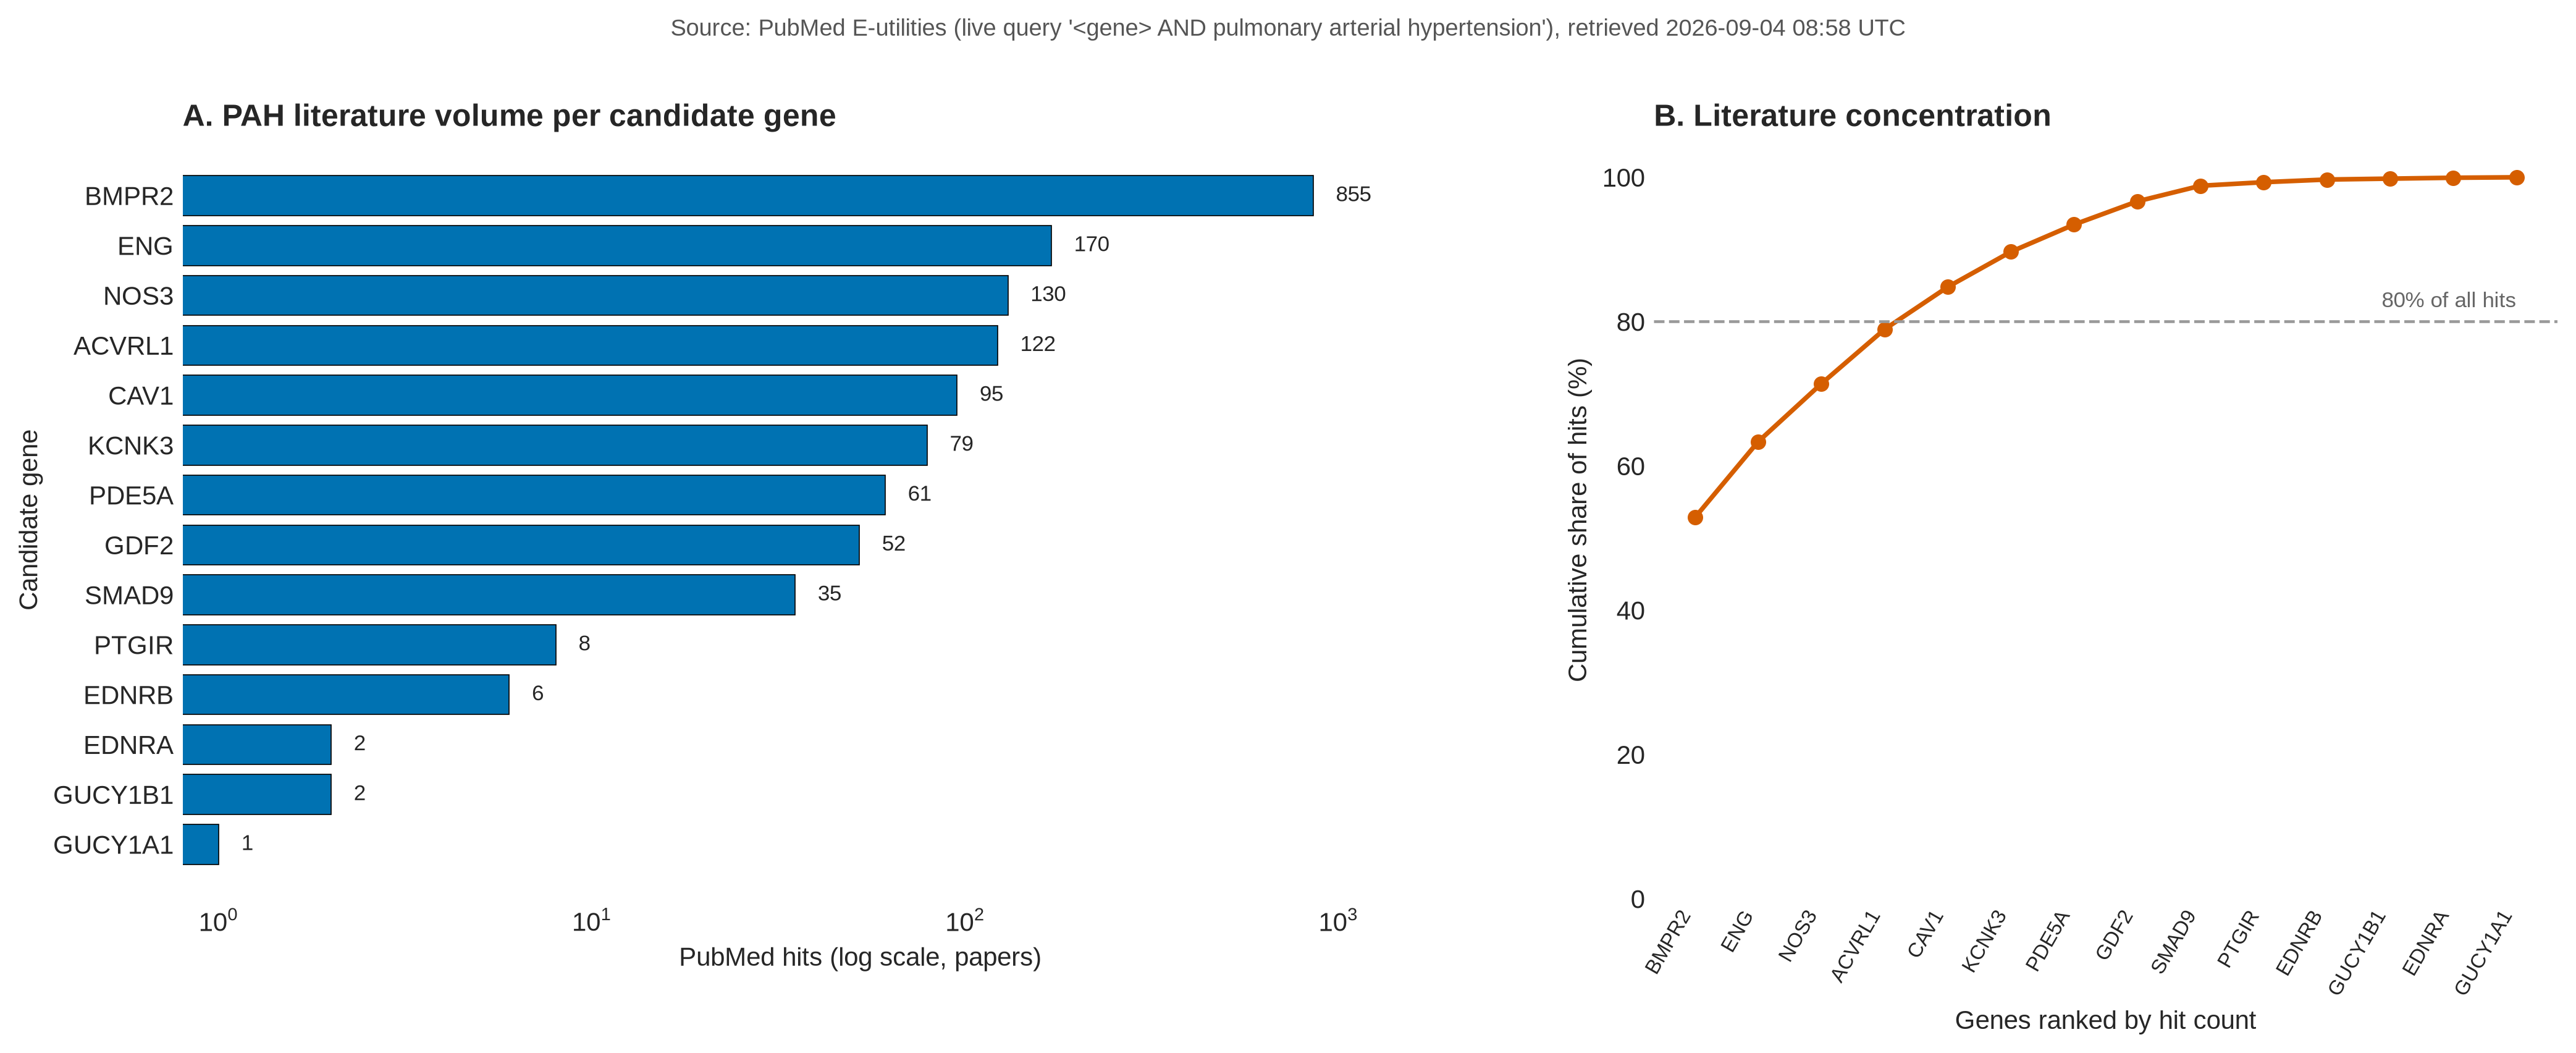

전체 히트 합계  : 1,618건
최다 문헌 유전자: BMPR2 (855건, 전체의 52.8%)
최소 문헌 유전자: GUCY1A1 (1건)
상위 5개 유전자가 전체 문헌의 80%를 차지합니다


In [6]:
# --- 시각화 공통 설정 (이후 셀에서 재사용) ---------------------------------
import matplotlib as mpl

OKABE = {
    "black":  "#000000", "orange": "#E69F00", "skyblue": "#56B4E9",
    "green":  "#009E73", "yellow": "#F0E442", "blue":    "#0072B2",
    "vermil": "#D55E00", "purple": "#CC79A7", "grey":    "#999999",
}
OKABE_CYCLE = [OKABE[k] for k in
               ("blue", "orange", "green", "vermil", "purple", "skyblue")]

mpl.rcParams.update({
    "savefig.dpi": 300, "figure.dpi": 100, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
# 노트북에 임베드되는 PNG를 300 DPI로 (화면에서는 브라우저가 축소해 보여 줍니다)
try:
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic(
            "config",
            "InlineBackend.print_figure_kwargs = {'dpi': 300, 'bbox_inches': 'tight'}")
except Exception:
    pass

# --- Figure: 유전자별 PubMed 히트 수 ----------------------------------------
hits = pd.Series(LIT_HITS_BY_GENE).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.6),
                               gridspec_kw={"width_ratios": [1.5, 1.0]})

bars = ax1.barh(hits.index, np.maximum(hits.values, 0.8),
                color=OKABE["blue"], edgecolor="black", linewidth=0.4)
ax1.set_xscale("log")
ax1.set_xlabel("PubMed hits (log scale, papers)")
ax1.set_ylabel("Candidate gene")
ax1.set_title("A. PAH literature volume per candidate gene", loc="left", fontweight="bold")
for b, v in zip(bars, hits.values):
    ax1.text(max(v, 0.8) * 1.15, b.get_y() + b.get_height() / 2,
             f"{v:,}", va="center", fontsize=8.5)
ax1.set_xlim(0.8, max(hits.max(), 1) * 4.0)

share = hits.sort_values(ascending=False)
cum = 100.0 * share.cumsum() / max(share.sum(), 1)
ax2.plot(range(1, len(cum) + 1), cum.values, "o-", color=OKABE["vermil"],
         lw=1.8, markersize=5)
ax2.axhline(80, color=OKABE["grey"], ls="--", lw=1.1)
ax2.text(len(cum), 82, "80% of all hits", ha="right", fontsize=8.5, color="#666666")
ax2.set_xticks(range(1, len(cum) + 1))
ax2.set_xticklabels(share.index, rotation=60, ha="right", fontsize=8)
ax2.set_ylim(0, 105)
ax2.set_xlabel("Genes ranked by hit count")
ax2.set_ylabel("Cumulative share of hits (%)")
ax2.set_title("B. Literature concentration", loc="left", fontweight="bold")

fig.suptitle(f"Source: PubMed E-utilities (live query '<gene> AND pulmonary arterial "
             f"hypertension'), retrieved {LIT_FETCH_TS}",
             fontsize=9, color="#555555", y=1.005)
plt.tight_layout()
plt.show()

_n80 = int((cum <= 80).sum()) + 1
print(f"전체 히트 합계  : {LIT_TOTAL_HITS:,}건")
print(f"최다 문헌 유전자: {share.index[0]} ({share.iloc[0]:,}건, "
      f"전체의 {100*share.iloc[0]/max(share.sum(),1):.1f}%)")
print(f"최소 문헌 유전자: {share.index[-1]} ({share.iloc[-1]:,}건)")
print(f"상위 {_n80}개 유전자가 전체 문헌의 80%를 차지합니다")


### 4-2. 연도별 논문 추이 — 어느 표적이 최근 뜨는가

같은 검색 결과를 발행연도로 나눠 봅니다. 왼쪽은 표본이 많은 상위 6개 유전자의 연도별 논문 수,
오른쪽은 유전자별 **논문 중앙 연도**(점)와 최소-최대 범위(막대)입니다.
중앙 연도가 오른쪽에 있을수록 최근에 연구가 몰린 표적입니다.
표본은 유전자당 최근 1000건 이하입니다. 이 후보군에서는 최다 유전자도 1000건 미만이라
사실상 전수이지만, 상한에 걸린 유전자가 있으면 위 셀이 그 목록을 출력합니다.

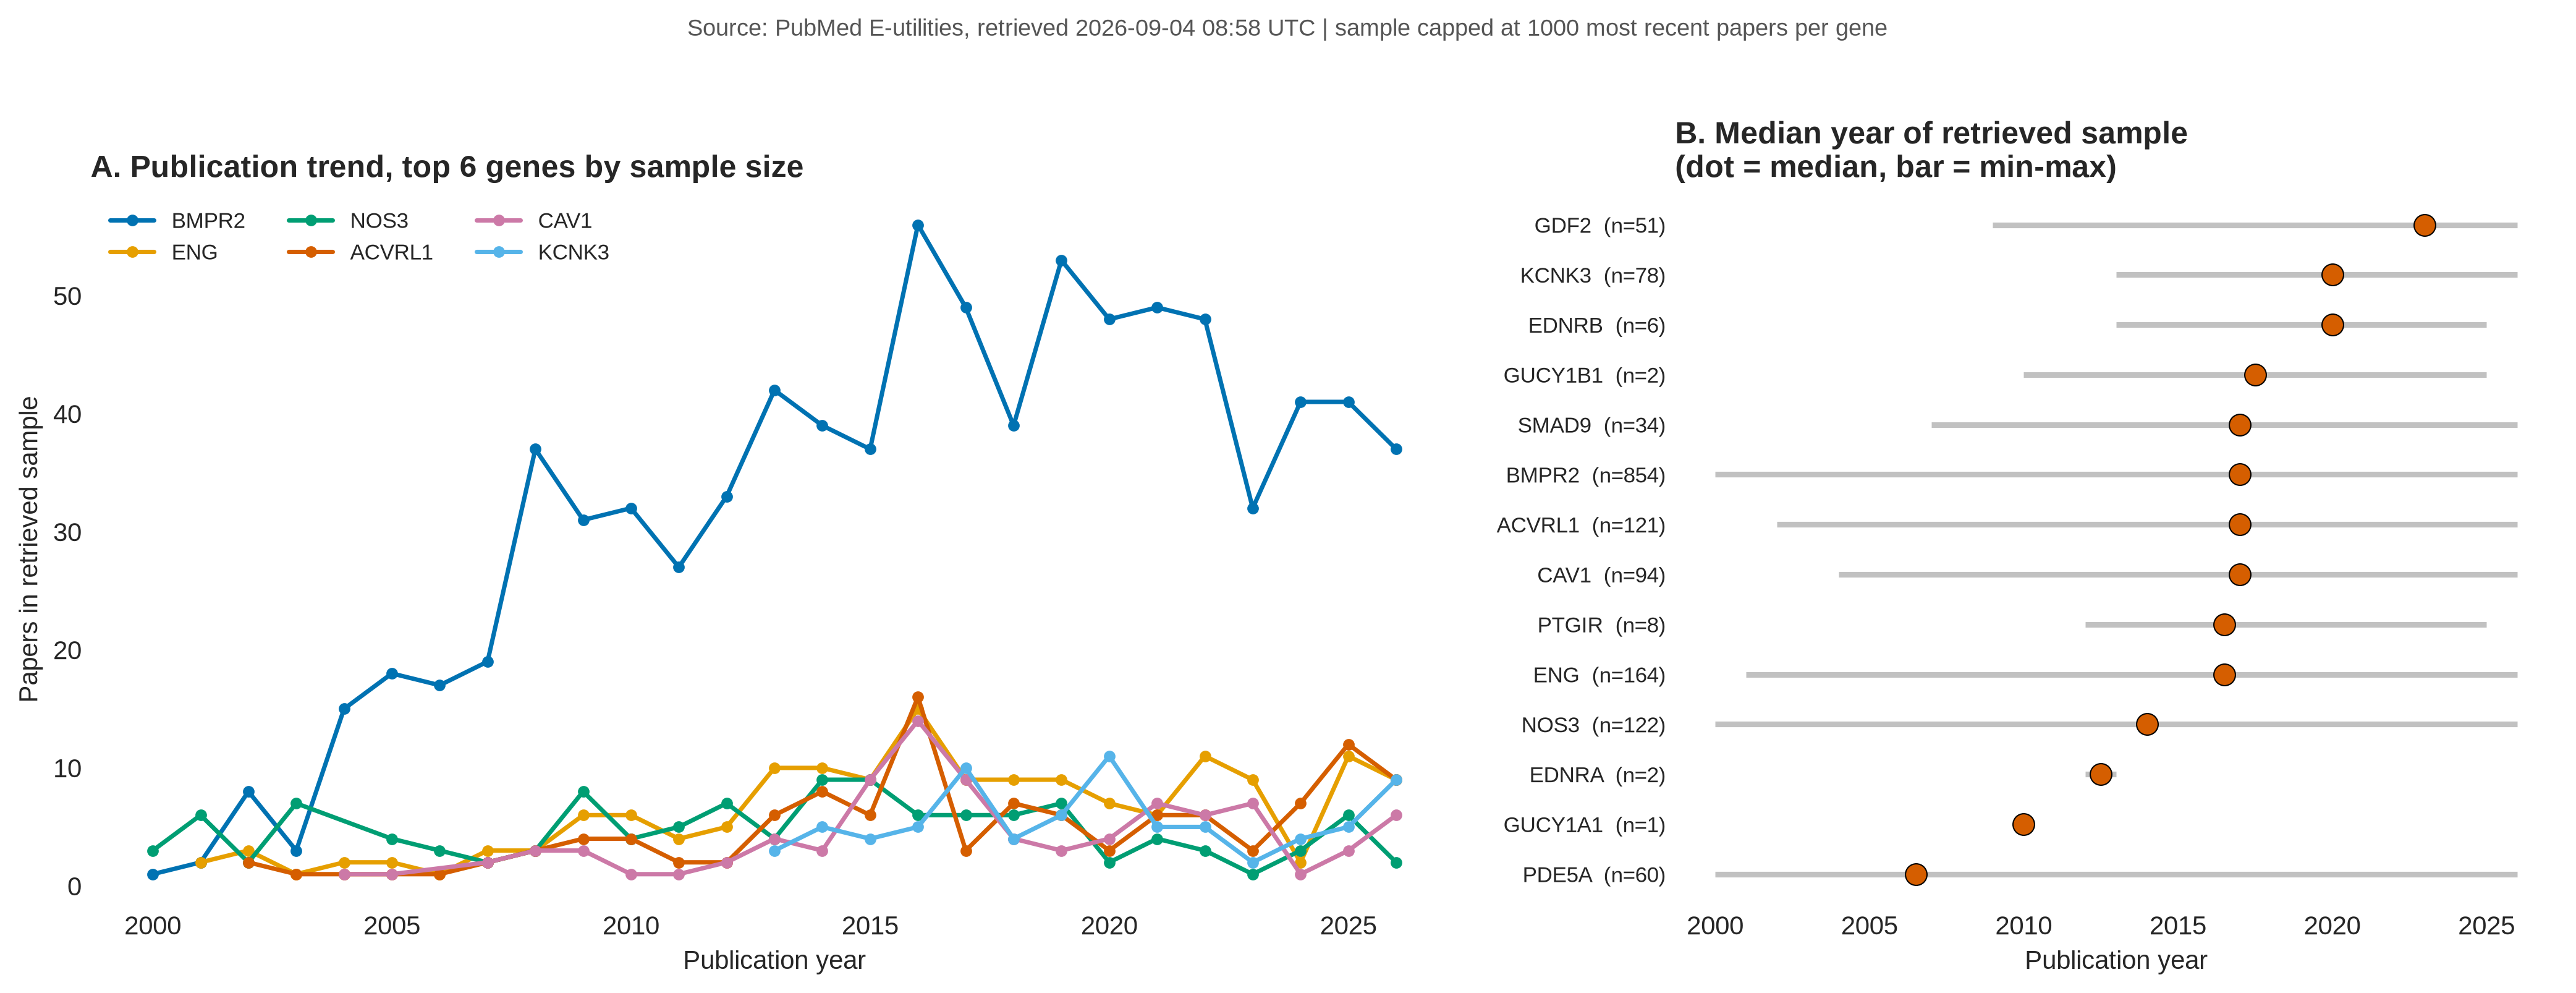

연도 분석 대상 : 1,597건 (2000년 이후)
가장 '최근형' 표적: GDF2 (중앙 연도 2023)
가장 '고전형' 표적: PDE5A (중앙 연도 2006)


In [7]:
if lit_year_df.empty:
    print("⚠️ 연도 데이터가 없어 이 그림은 건너뜁니다 (NCBI 응답 실패).")
else:
    YEAR_MIN = 2000
    ydf = lit_year_df[(lit_year_df["Year"] >= YEAR_MIN) & (lit_year_df["Year"] <= THIS_YEAR)]

    counts = ydf.groupby(["Gene", "Year"]).size().rename("N").reset_index()
    top6 = ydf.groupby("Gene").size().sort_values(ascending=False).head(6).index.tolist()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2),
                                   gridspec_kw={"width_ratios": [1.55, 1.0]})

    for g, c in zip(top6, OKABE_CYCLE):
        sub = counts[counts["Gene"] == g].sort_values("Year")
        ax1.plot(sub["Year"], sub["N"], "-o", ms=3.5, lw=1.7, color=c, label=g)
    ax1.set_xlabel("Publication year")
    ax1.set_ylabel("Papers in retrieved sample")
    ax1.set_title(f"A. Publication trend, top {len(top6)} genes by sample size",
                  loc="left", fontweight="bold")
    ax1.legend(ncol=3, fontsize=8.5, frameon=False)

    med = (ydf.groupby("Gene")["Year"]
           .agg(median="median", n="size", first="min", last="max")
           .sort_values("median"))
    ypos = np.arange(len(med))
    ax2.hlines(ypos, med["first"], med["last"], color=OKABE["grey"], lw=2.2, alpha=0.6)
    ax2.scatter(med["median"], ypos, s=70, color=OKABE["vermil"],
                edgecolor="black", linewidth=0.5, zorder=3)
    ax2.set_yticks(ypos)
    ax2.set_yticklabels([f"{g}  (n={int(r)})" for g, r in zip(med.index, med["n"])],
                        fontsize=8.5)
    ax2.set_xlabel("Publication year")
    ax2.set_title("B. Median year of retrieved sample\n(dot = median, bar = min-max)",
                  loc="left", fontweight="bold")
    ax2.grid(axis="y", alpha=0.15)

    fig.suptitle(f"Source: PubMed E-utilities, retrieved {LIT_FETCH_TS} | "
                 f"sample capped at {LIT_MAX_FETCH} most recent papers per gene",
                 fontsize=9, color="#555555", y=1.02)
    plt.tight_layout()
    plt.show()

    newest = med.sort_values("median", ascending=False)
    print(f"연도 분석 대상 : {len(ydf):,}건 ({YEAR_MIN}년 이후)")
    print(f"가장 '최근형' 표적: {newest.index[0]} (중앙 연도 {newest['median'].iloc[0]:.0f})")
    print(f"가장 '고전형' 표적: {newest.index[-1]} (중앙 연도 {newest['median'].iloc[-1]:.0f})")


### 4-3. 유전자 × 연도 히트맵과 공동 출현 네트워크

왼쪽 히트맵은 어느 유전자가 어느 시기에 집중적으로 연구됐는지를 한 장에 보여 줍니다.
오른쪽 네트워크는 **같은 논문(PMID)에 함께 등장한 유전자 쌍**을 연결한 것입니다.
선이 굵을수록 함께 다뤄진 논문이 많다는 뜻이고, 이는 곧 같은 경로·기전으로 묶여 논의되는
표적 군집을 뜻합니다 (예: BMP/activin 축 vs. NO-cGMP 축). 연결이 없는 노드는
이 표본 안에서 다른 후보와 함께 논의된 적이 없다는 뜻입니다.

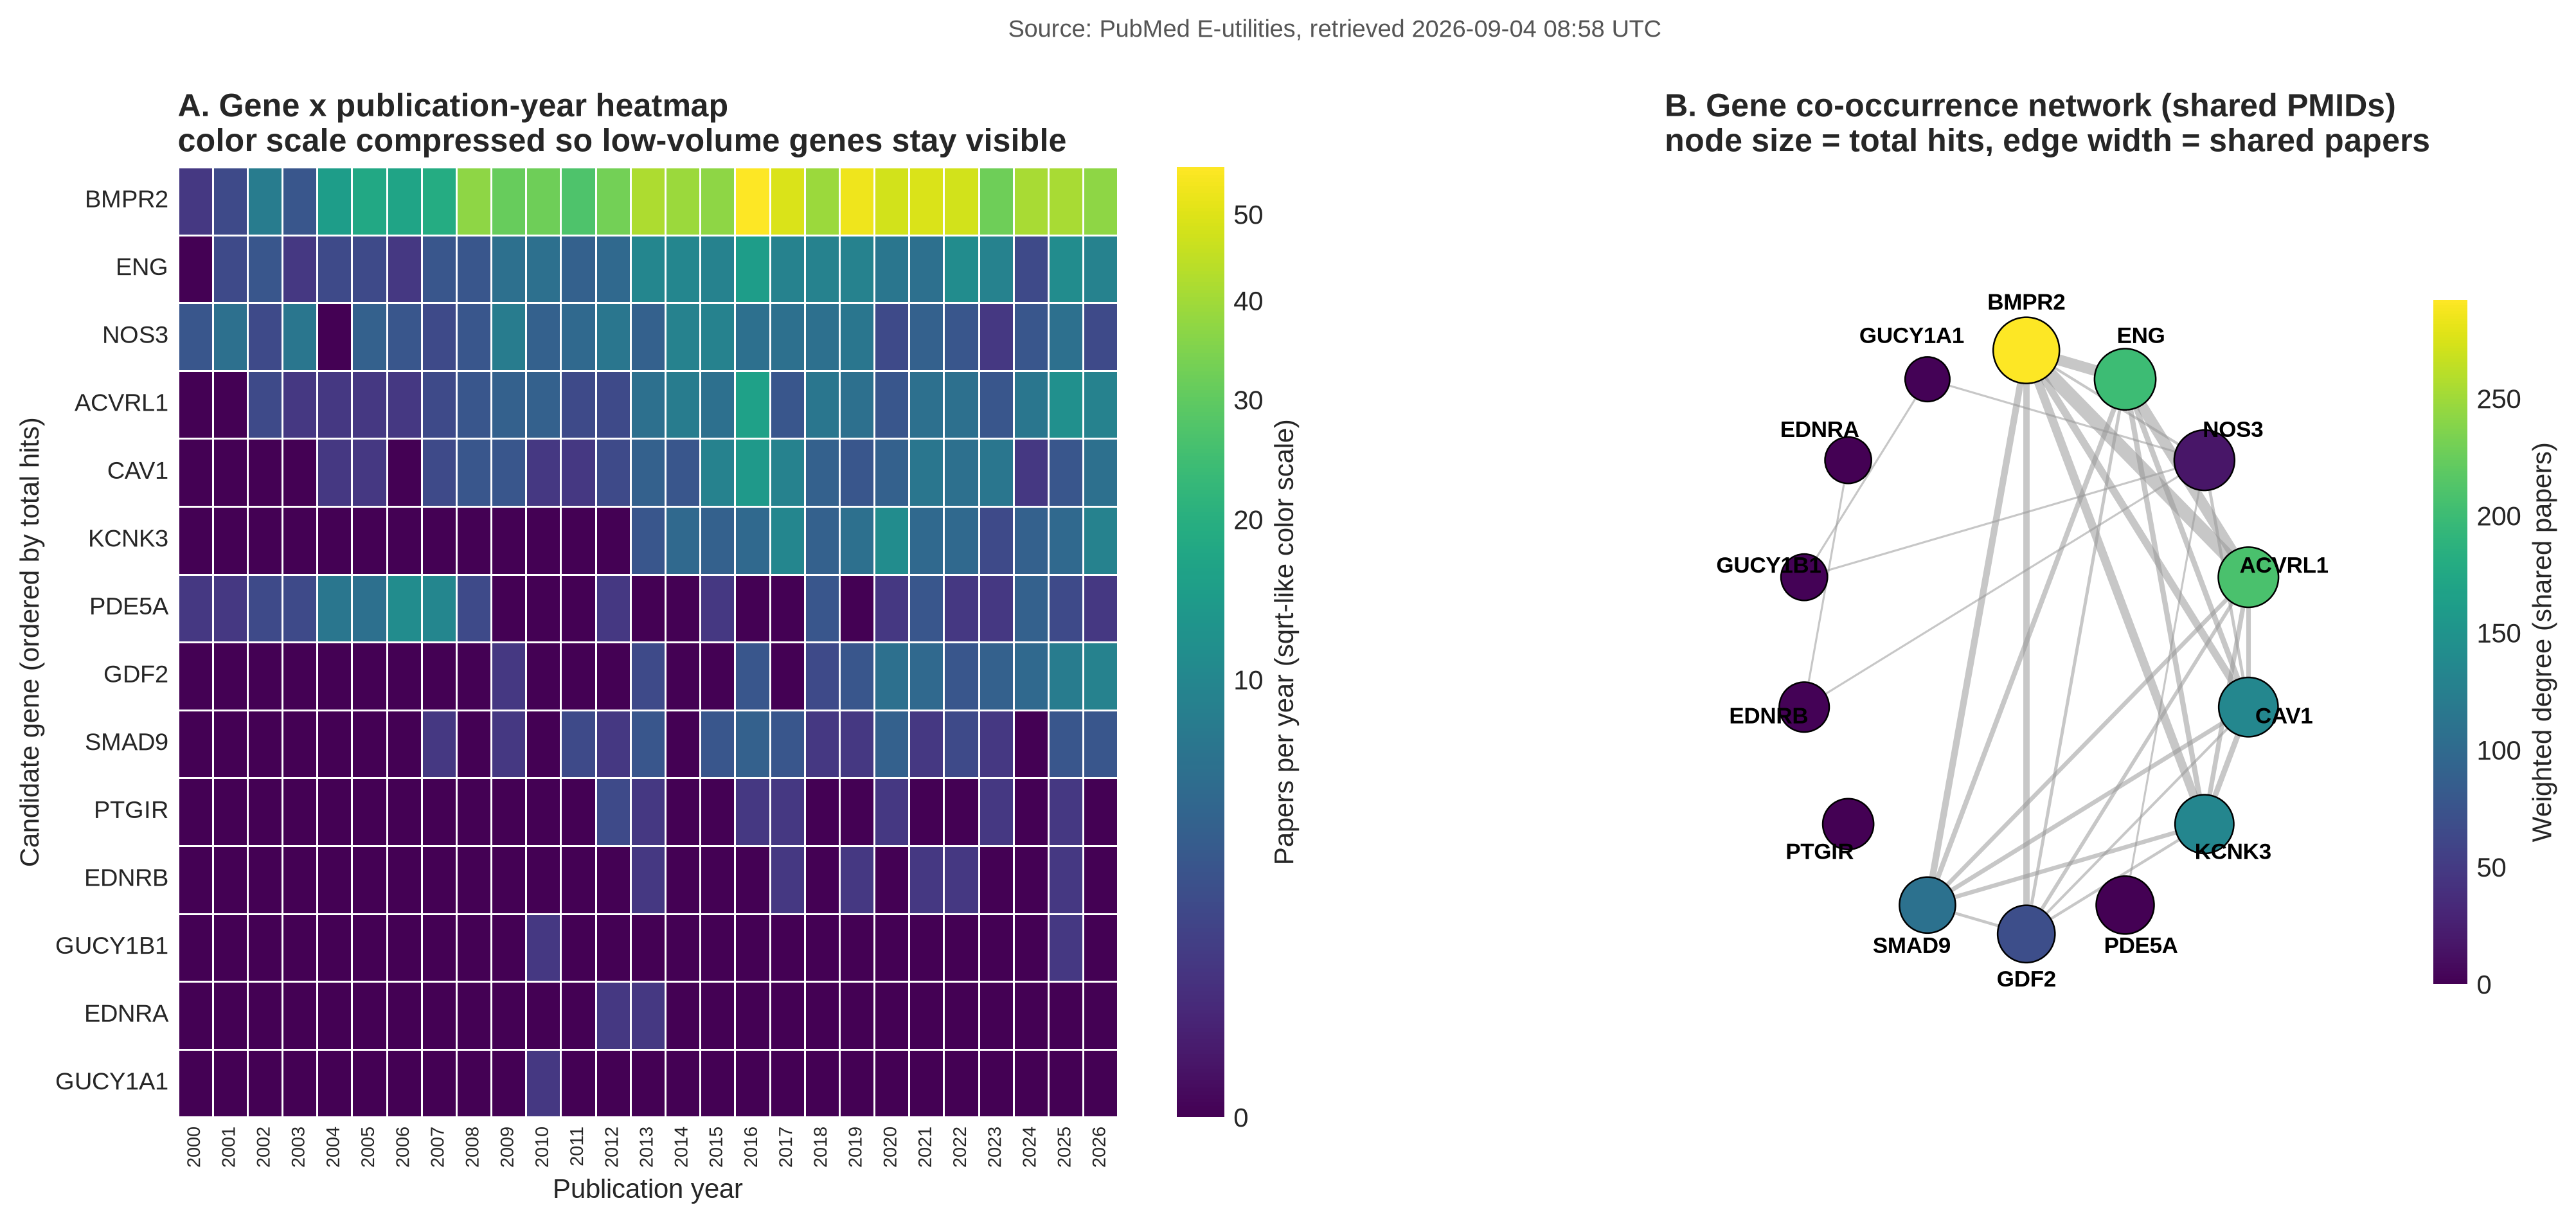

네트워크: 노드 14개 / 엣지 29개
가장 강한 연결: BMPR2 - ACVRL1 (공유 논문 81건)
고립 노드(공유 논문 없음): ['PTGIR']


In [8]:
if lit_year_df.empty:
    print("⚠️ 연도 데이터가 없어 히트맵을 건너뜁니다.")
else:
    fig = plt.figure(figsize=(16, 6.4))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1.0], wspace=0.30)

    # --- (A) Gene x Year 히트맵 ---
    axh = fig.add_subplot(gs[0])
    ydf2 = lit_year_df[lit_year_df["Year"] >= 2000]
    order = sorted(LIT_HITS_BY_GENE, key=LIT_HITS_BY_GENE.get, reverse=True)
    pivot = (ydf2.pivot_table(index="Gene", columns="Year", values="PMID",
                              aggfunc="count", fill_value=0)
             .reindex(order).fillna(0))
    from matplotlib.colors import PowerNorm
    sns.heatmap(pivot, cmap="viridis", ax=axh, linewidths=0.3, linecolor="white",
                norm=PowerNorm(gamma=0.45, vmin=0, vmax=max(pivot.to_numpy().max(), 1)),
                cbar_kws={"label": "Papers per year (sqrt-like color scale)"})
    axh.set_title("A. Gene x publication-year heatmap\n"
                  "color scale compressed so low-volume genes stay visible",
                  loc="left", fontweight="bold")
    axh.set_xlabel("Publication year")
    axh.set_ylabel("Candidate gene (ordered by total hits)")
    axh.tick_params(axis="x", rotation=90, labelsize=7)
    axh.tick_params(axis="y", rotation=0, labelsize=9)

    # --- (B) 공동 출현 네트워크 (같은 PMID 공유) ---
    axn = fig.add_subplot(gs[1])
    pmid_sets = {g: set(v) for g, v in LIT_PMIDS_BY_GENE.items()}
    G = nx.Graph()
    for g in TARGET_GENES:
        G.add_node(g, hits=LIT_HITS_BY_GENE.get(g, 0))
    for i, a in enumerate(TARGET_GENES):
        for b in TARGET_GENES[i + 1:]:
            w = len(pmid_sets.get(a, set()) & pmid_sets.get(b, set()))
            if w > 0:
                G.add_edge(a, b, weight=w)

    if G.number_of_edges() == 0:
        axn.text(0.5, 0.5, "No shared PMIDs in the retrieved sample\n"
                           "(no co-occurrence edges to draw)",
                 ha="center", va="center", fontsize=11, color="#777777")
        axn.axis("off")
    else:
        # 원형 배치: 노드가 겹치지 않아 14개 라벨이 모두 읽힙니다.
        # 군집 구조는 엣지 굵기와 노드 색(weighted degree)이 대신 전달합니다.
        ring = sorted(G.nodes, key=lambda n: -G.nodes[n]["hits"])
        _ang = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, len(ring), endpoint=False)
        pos = {n: (float(np.cos(a)), float(np.sin(a))) for n, a in zip(ring, _ang)}
        sizes = [240 + 55 * np.log1p(G.nodes[n]["hits"]) for n in G.nodes]
        wmax = max(d["weight"] for *_x, d in G.edges(data=True))
        widths = [0.7 + 4.5 * d["weight"] / wmax for *_x, d in G.edges(data=True)]
        deg_w = dict(G.degree(weight="weight"))
        nx.draw_networkx_edges(G, pos, ax=axn, width=widths,
                               edge_color=OKABE["grey"], alpha=0.55)
        nc = nx.draw_networkx_nodes(G, pos, ax=axn, node_size=sizes,
                                    node_color=[deg_w[n] for n in G.nodes],
                                    cmap="viridis", edgecolors="black", linewidths=0.6)
        lbl_pos = {n: (p[0] * 1.16, p[1] * 1.16) for n, p in pos.items()}
        nx.draw_networkx_labels(G, lbl_pos, ax=axn, font_size=8.5, font_weight="bold")
        axn.margins(0.24)
        plt.colorbar(nc, ax=axn, shrink=0.72, label="Weighted degree (shared papers)")
        axn.axis("off")
    axn.set_title("B. Gene co-occurrence network (shared PMIDs)\n"
                  "node size = total hits, edge width = shared papers",
                  loc="left", fontweight="bold")

    fig.suptitle(f"Source: PubMed E-utilities, retrieved {LIT_FETCH_TS}",
                 fontsize=9, color="#555555", y=1.0)
    plt.show()

    print(f"네트워크: 노드 {G.number_of_nodes()}개 / 엣지 {G.number_of_edges()}개")
    if G.number_of_edges():
        s = max(G.edges(data=True), key=lambda e: e[2]["weight"])
        print(f"가장 강한 연결: {s[0]} - {s[1]} (공유 논문 {s[2]['weight']}건)")
        iso = [n for n in G.nodes if G.degree(n) == 0]
        print(f"고립 노드(공유 논문 없음): {iso if iso else '없음'}")


## 5. 멀티에이전트 시스템 구축

In [9]:
# 상태 정의
class ResearchState(TypedDict):
    """LangGraph 노드들이 주고받는 연구 상태(유전자·논문·에이전트별 결과)."""
    gene_name: str
    papers: List[Dict]
    literature_summary: str
    mechanism_analysis: str
    clinical_relevance: str
    drug_potential: str
    final_score: Dict[str, float]
    reasoning: str

# Agent 프롬프트 템플릿들
literature_prompt = PromptTemplate(
    input_variables=["gene_name", "papers"],
    template="""
당신은 문헌 검토 전문가입니다. 다음 유전자에 대한 논문들을 분석하여 요약하세요.

유전자: {gene_name}
논문 정보 (PubMed에서 실제로 가져온 제목/초록):
{papers}

중요: 위에 주어진 문헌 정보에만 근거해 분석하세요. 주어지지 않은 논문, PMID, 수치를 지어내지 마세요.
문헌이 0건이면 "근거 부족"이라고 명시하고 점수를 낮게 주세요.

다음 사항들을 포함하여 종합적으로 분석하세요:
1. 연구 현황 (논문 수, 최신성)
2. 주요 발견사항
3. 연구 품질 및 신뢰성
4. 연구 격차 및 한계

점수 (1-10):
요약:
"""
)

mechanism_prompt = PromptTemplate(
    input_variables=["gene_name", "literature_summary"],
    template="""
당신은 분자생물학 전문가입니다. 다음 유전자의 분자적 메커니즘을 분석하세요.

유전자: {gene_name}
문헌 요약: {literature_summary}

다음 사항들을 분석하세요:
1. 분자적 기능 및 pathway
2. 질병(PAH) 발생/진행에서의 역할
3. 변이/발현 변화의 임상적 의미
4. 다른 유전자와의 상호작용

점수 (1-10):
분석:
"""
)

clinical_prompt = PromptTemplate(
    input_variables=["gene_name", "mechanism_analysis"],
    template="""
당신은 폐동맥고혈압(PAH) 임상 전문의입니다. 다음 유전자의 임상적 관련성을 평가하세요.

유전자: {gene_name}
메커니즘 분석: {mechanism_analysis}

다음 사항들을 평가하세요:
1. 환자 하위군 정의 가능성
2. 예후 예측 바이오마커로서의 가치
3. 치료 반응 예측 가능성
4. 임상시험 결과 및 현재 가이드라인

점수 (1-10):
평가:
"""
)

drug_prompt = PromptTemplate(
    input_variables=["gene_name", "clinical_relevance"],
    template="""
당신은 약물개발 전문가입니다. 다음 유전자의 약물 개발 가능성을 평가하세요.

유전자: {gene_name}
임상적 관련성: {clinical_relevance}

다음 사항들을 평가하세요:
1. Druggability (약물 표적으로서의 적합성)
2. 기존 승인 약물 및 파이프라인
3. 시장 규모 및 상업적 가치
4. 개발 위험도 및 기술적 난이도

점수 (1-10):
평가:
"""
)

judge_prompt = PromptTemplate(
    input_variables=["gene_name", "literature_summary", "mechanism_analysis",
                    "clinical_relevance", "drug_potential"],
    template="""
당신은 종합 평가 판정관입니다. 다음 정보를 바탕으로 최종 점수를 산정하세요.

유전자: {gene_name}

문헌 검토: {literature_summary}
메커니즘 분석: {mechanism_analysis}
임상적 관련성: {clinical_relevance}
약물 개발 가능성: {drug_potential}

각 영역의 점수를 추출하고 가중평균을 계산하세요:
- 문헌 검토 (25%)
- 메커니즘 분석 (25%)
- 임상적 관련성 (25%)
- 약물 개발 가능성 (25%)

결과를 다음 형식으로 제시하세요:
문헌_점수: X
메커니즘_점수: X
임상_점수: X
약물_점수: X
최종_점수: X.XX
순위_등급: [S/A/B/C/D]
핵심_근거: [한 줄 요약]
"""
)

print("✅ 에이전트 프롬프트 템플릿 정의 완료!")

✅ 에이전트 프롬프트 템플릿 정의 완료!


In [10]:
# 에이전트 노드 함수들
def literature_agent(state: ResearchState) -> ResearchState:
    """문헌 검토 에이전트"""
    print(f"📚 문헌 검토 중: {state['gene_name']}")

    # 논문 검색
    papers = pubmed.search_gene_papers(state["gene_name"], max_results=10)
    if not papers:
        # 데이터가 없으면 지어내지 말고 그 사실을 그대로 프롬프트에 알립니다
        papers_text = "(PubMed 검색 결과 0건 - 근거 문헌 없음)"
    else:
        papers_text = "\n\n".join(
            f"- [{p['pmid']}] {p['title']} ({p['year']}, {p['journal']})\n  {p['abstract'][:600]}"
            for p in papers
        )

    # LLM 분석
    result = run_prompt(literature_prompt, gene_name=state["gene_name"], papers=papers_text)

    state["papers"] = papers
    state["literature_summary"] = result
    return state

def mechanism_agent(state: ResearchState) -> ResearchState:
    """분자 메커니즘 분석 에이전트"""
    print(f"🧬 메커니즘 분석 중: {state['gene_name']}")

    result = run_prompt(mechanism_prompt,
        gene_name=state["gene_name"],
        literature_summary=state["literature_summary"]
    )

    state["mechanism_analysis"] = result
    return state

def clinical_agent(state: ResearchState) -> ResearchState:
    """임상적 관련성 평가 에이전트"""
    print(f"🏥 임상 평가 중: {state['gene_name']}")

    result = run_prompt(clinical_prompt,
        gene_name=state["gene_name"],
        mechanism_analysis=state["mechanism_analysis"]
    )

    state["clinical_relevance"] = result
    return state

def drug_agent(state: ResearchState) -> ResearchState:
    """약물 개발 가능성 평가 에이전트"""
    print(f"💊 약물 평가 중: {state['gene_name']}")

    result = run_prompt(drug_prompt,
        gene_name=state["gene_name"],
        clinical_relevance=state["clinical_relevance"]
    )

    state["drug_potential"] = result
    return state

def judge_agent(state: ResearchState) -> ResearchState:
    """종합 평가 에이전트"""
    print(f"⚖️ 최종 평가 중: {state['gene_name']}")

    result = run_prompt(judge_prompt,
        gene_name=state["gene_name"],
        literature_summary=state["literature_summary"],
        mechanism_analysis=state["mechanism_analysis"],
        clinical_relevance=state["clinical_relevance"],
        drug_potential=state["drug_potential"]
    )

    # 점수 추출 — 모델이 "**최종_점수**: 8.5", "- 최종 점수 : 8.5" 처럼
    # 꾸며 써도 읽는다. 못 읽으면 지어내지 않고 빈 dict 로 둔다 (이후 NaN 처리).
    scores = {}
    for line in result.split("\n"):
        m = re.match(r"\s*[-*•]?\s*\**\s*([가-힣A-Za-z]+)[ _]?점수\s*\**\s*[:：]"
                     r"\s*\**\s*([0-9]+(?:\.[0-9]+)?)", line)
        if m:
            scores[f"{m.group(1)}_점수"] = float(m.group(2))

    state["final_score"] = scores
    state["reasoning"] = result
    return state

print("✅ 에이전트 노드 함수 정의 완료!")

✅ 에이전트 노드 함수 정의 완료!


## 6. LangGraph 워크플로우 구성

In [11]:
# LangGraph 워크플로우 생성
def create_research_workflow():
    """다섯 에이전트를 순서대로 잇는 LangGraph 워크플로우를 만들어 컴파일한다."""
    workflow = StateGraph(ResearchState)

    # 노드 추가
    workflow.add_node("literature", literature_agent)
    workflow.add_node("mechanism", mechanism_agent)
    workflow.add_node("clinical", clinical_agent)
    workflow.add_node("drug", drug_agent)
    workflow.add_node("judge", judge_agent)

    # 엣지 추가 (순차적 워크플로우)
    workflow.set_entry_point("literature")
    workflow.add_edge("literature", "mechanism")
    workflow.add_edge("mechanism", "clinical")
    workflow.add_edge("clinical", "drug")
    workflow.add_edge("drug", "judge")
    workflow.add_edge("judge", END)

    return workflow.compile()

# 워크플로우 컴파일
research_app = create_research_workflow()
print("✅ LangGraph 워크플로우 생성 완료!")

# 워크플로우 시각화
try:
    # 워크플로우 구조를 텍스트로 표시
    print("\n📊 워크플로우 구조:")
    print("Literature Agent → Mechanism Agent → Clinical Agent → Drug Agent → Judge Agent")
    print("     ↓                ↓                 ↓               ↓            ↓")
    print("  논문 검색        메커니즘 분석      임상 평가       약물 평가      최종 점수")
except Exception as e:
    print(f"시각화 생략: {e}")

✅ LangGraph 워크플로우 생성 완료!

📊 워크플로우 구조:
Literature Agent → Mechanism Agent → Clinical Agent → Drug Agent → Judge Agent
     ↓                ↓                 ↓               ↓            ↓
  논문 검색        메커니즘 분석      임상 평가       약물 평가      최종 점수


## 7. 표적 후보 유전자 평가 실행

In [12]:
# 평가 대상 유전자 TARGET_GENES 는 4절(PubMed 계량 수집)에서 이미 정의했습니다.
# 그 절의 실검색 결과(LIT_PAPERS_BY_GENE)를 여기서 재사용하므로 중복 검색하지 않습니다.
print(f"🎯 평가 대상: {len(TARGET_GENES)}개 유전자")
print(f"유전자 목록: {', '.join(TARGET_GENES)}")

# 평가 결과 저장소
gene_evaluations = {}

# 각 유전자별 평가 실행
for i, gene in enumerate(TARGET_GENES, 1):
    print(f"\n{'='*50}")
    print(f"🧬 [{i}/{len(TARGET_GENES)}] {gene} 평가 시작")
    print(f"{'='*50}")

    try:
        if not LLM_AVAILABLE:
            # LLM 없이도 PubMed 문헌은 실제로 확보돼 있습니다 (4절 수집분).
            # 점수는 만들어내지 않고 비워 둡니다.
            papers = LIT_PAPERS_BY_GENE.get(gene, [])
            gene_evaluations[gene] = {
                "gene_name": gene,
                "papers": papers,
                "final_score": {},        # 점수 없음 -> 이후 NaN 처리
                "reasoning": LLM_NOT_RUN,
                "llm_ran": False,
            }
            print(f"⏭️  {gene}: LLM 미실행 — PubMed 초록 {len(papers)}건만 확보")
            continue

        # 초기 상태 설정
        initial_state = {
            "gene_name": gene,
            "papers": [],
            "literature_summary": "",
            "mechanism_analysis": "",
            "clinical_relevance": "",
            "drug_potential": "",
            "final_score": {},
            "reasoning": ""
        }

        # 워크플로우 실행
        result = research_app.invoke(initial_state)
        result["llm_ran"] = True
        gene_evaluations[gene] = result

        # 중간 결과 출력
        if "final_score" in result and result["final_score"]:
            final_score = result["final_score"].get("최종_점수", 0)
            print(f"✅ {gene} 평가 완료! 최종 점수: {final_score}")
        else:
            print(f"✅ {gene} 평가 완료! (점수 파싱 실패)")

        # API 호출 제한 고려하여 잠시 대기
        time.sleep(2)

    except Exception as e:
        print(f"❌ {gene} 평가 중 오류 발생: {e}")
        # 오류가 나도 점수를 지어내지 않습니다 (기존의 기본값 5.0 은 가짜 수치였습니다)
        gene_evaluations[gene] = {
            "gene_name": gene,
            "papers": LIT_PAPERS_BY_GENE.get(gene, []),
            "final_score": {},
            "reasoning": f"평가 중 오류 발생: {e}",
            "llm_ran": False,
        }

print(f"\n🎉 모든 유전자 평가 완료! 총 {len(gene_evaluations)}개 결과")

🎯 평가 대상: 14개 유전자
유전자 목록: PDE5A, GUCY1A1, GUCY1B1, EDNRA, EDNRB, PTGIR, NOS3, BMPR2, ACVRL1, ENG, GDF2, KCNK3, CAV1, SMAD9

🧬 [1/14] PDE5A 평가 시작
⏭️  PDE5A: LLM 미실행 — PubMed 초록 10건만 확보

🧬 [2/14] GUCY1A1 평가 시작
⏭️  GUCY1A1: LLM 미실행 — PubMed 초록 1건만 확보

🧬 [3/14] GUCY1B1 평가 시작
⏭️  GUCY1B1: LLM 미실행 — PubMed 초록 2건만 확보

🧬 [4/14] EDNRA 평가 시작
⏭️  EDNRA: LLM 미실행 — PubMed 초록 2건만 확보

🧬 [5/14] EDNRB 평가 시작
⏭️  EDNRB: LLM 미실행 — PubMed 초록 6건만 확보

🧬 [6/14] PTGIR 평가 시작
⏭️  PTGIR: LLM 미실행 — PubMed 초록 8건만 확보

🧬 [7/14] NOS3 평가 시작
⏭️  NOS3: LLM 미실행 — PubMed 초록 10건만 확보

🧬 [8/14] BMPR2 평가 시작
⏭️  BMPR2: LLM 미실행 — PubMed 초록 10건만 확보

🧬 [9/14] ACVRL1 평가 시작
⏭️  ACVRL1: LLM 미실행 — PubMed 초록 9건만 확보

🧬 [10/14] ENG 평가 시작
⏭️  ENG: LLM 미실행 — PubMed 초록 9건만 확보

🧬 [11/14] GDF2 평가 시작
⏭️  GDF2: LLM 미실행 — PubMed 초록 9건만 확보

🧬 [12/14] KCNK3 평가 시작
⏭️  KCNK3: LLM 미실행 — PubMed 초록 9건만 확보

🧬 [13/14] CAV1 평가 시작
⏭️  CAV1: LLM 미실행 — PubMed 초록 9건만 확보

🧬 [14/14] SMAD9 평가 시작
⏭️  SMAD9: LLM 미실행 — PubMed 초록 9건만 확보

🎉 모든 유전자 평가 완료! 총 14개 결과


## 8. 토너먼트 평가 시스템

In [13]:
# 토너먼트 평가 프롬프트
tournament_prompt = PromptTemplate(
    input_variables=["gene1", "gene2", "analysis1", "analysis2"],
    template="""
당신은 Tournament Judge입니다. 다음 두 유전자를 폐동맥고혈압(PAH) 치료 표적으로서 비교 평가하세요:

🥊 유전자 A: {gene1}
평가 결과: {analysis1}

🥊 유전자 B: {gene2}
평가 결과: {analysis2}

다음 기준으로 어느 유전자가 더 우수한 치료 표적인지 판단하세요:
1. 과학적 근거의 충실성
2. 임상적 관련성과 환자 혜택
3. 약물 개발 실현 가능성
4. 시장성과 상업적 가치

결과를 다음 형식으로 제시하세요:
승자: A 또는 B
점수차: X점 (1-5점 범위)
핵심 이유: [한 줄로 요약]
상세 근거: [각 기준별 비교 분석]
"""
)

def tournament_evaluation(gene1, gene2, eval1, eval2):
    """두 유전자 간 토너먼트 평가"""
    # 분석 요약 추출
    analysis1 = eval1.get("reasoning", f"{gene1} 분석 결과")
    analysis2 = eval2.get("reasoning", f"{gene2} 분석 결과")

    result = run_prompt(tournament_prompt,
        gene1=gene1, gene2=gene2,
        analysis1=analysis1[:500],  # 길이 제한
        analysis2=analysis2[:500]
    )

    return result

# 상위 8개 유전자로 토너먼트 실시
print("🏆 토너먼트 평가 시작!")

# 시드(seeding) 기준
#  - LLM 실행 시  : judge_agent 가 산출한 최종 점수
#  - LLM 미실행 시: PubMed 실검색 히트 수 (실데이터).
#    점수를 지어내지 않기 위한 대체이며, 이때 대진표는 "구조 시연"이지 평가 결과가 아닙니다.
SEED_BY = "LLM final score" if LLM_AVAILABLE else "PubMed hit count"
print(f"시드 기준: {SEED_BY}")

scored_genes = []
for gene, evaluation in gene_evaluations.items():
    score = evaluation.get("final_score", {}).get("최종_점수", None)
    if not isinstance(score, (int, float)):
        score = float(LIT_HITS_BY_GENE.get(gene, 0)) if not LLM_AVAILABLE else float("nan")
    scored_genes.append((gene, float(score), evaluation))

# 점수순 정렬 (NaN 은 뒤로)
scored_genes.sort(key=lambda x: (x[1] != x[1], -(x[1] if x[1] == x[1] else 0.0)))
top_8_genes = scored_genes[:8]

unit = "점" if LLM_AVAILABLE else "건(PubMed)"
print(f"\n🥇 토너먼트 대상 상위 8개 유전자 ({SEED_BY}):")
for i, (gene, score, _) in enumerate(top_8_genes, 1):
    print(f"  {i}. {gene}: {score:,.2f}{unit}")

# 토너먼트 대진표 (상위 4개 준결승 + 결승)
tournament_log = []          # (gene_a, gene_b, raw_llm_text, winner) 실제 대결 기록
def parse_winner(text, gene_a, gene_b):
    """LLM 응답에서 '승자: A/B' 를 추출. 실패하면 None (임의로 정하지 않습니다)."""
    m = re.search(r"승자\s*[:：]\s*([AB])", text)
    if not m:
        return None
    return gene_a if m.group(1) == "A" else gene_b

if not LLM_AVAILABLE:
    print("\n⏭️  LLM 미실행 — 실제 쌍별 비교는 수행하지 않습니다.")
    print("    9-1절에서 대진표 '구조'만 그림으로 확인합니다 (승자 칸은 비워 둡니다).")
elif len(top_8_genes) >= 4:
    print("\n⚔️ 준결승전:")
    semifinal_pairs = [(top_8_genes[0], top_8_genes[3]), (top_8_genes[1], top_8_genes[2])]
    finalists = []
    for (g1, s1, e1), (g2, s2, e2) in semifinal_pairs:
        text = tournament_evaluation(g1, g2, e1, e2)
        winner = parse_winner(text, g1, g2)
        tournament_log.append({"A": g1, "B": g2, "winner": winner, "text": text})
        print(f"\n🥊 {g1} vs {g2} -> 승자: {winner if winner else '판정 불가(응답 형식 불일치)'}")
        print(text[:300] + "...")
        if winner:
            finalists.append(next(t for t in top_8_genes if t[0] == winner))

    if len(finalists) == 2:
        print("\n🏁 결승전:")
        (g1, s1, e1), (g2, s2, e2) = finalists
        text = tournament_evaluation(g1, g2, e1, e2)
        winner = parse_winner(text, g1, g2)
        tournament_log.append({"A": g1, "B": g2, "winner": winner, "text": text})
        print(f"🥊 {g1} vs {g2} -> 우승: {winner if winner else '판정 불가'}")
        print(text[:300] + "...")
    else:
        print("\n[안내] 준결승 승자 판정이 안 되어 결승은 생략합니다 (LLM 응답 형식 문제).")

print("\n✅ 토너먼트 평가 완료! 기록된 대결:", len(tournament_log), "건")

🏆 토너먼트 평가 시작!
시드 기준: PubMed hit count

🥇 토너먼트 대상 상위 8개 유전자 (PubMed hit count):
  1. BMPR2: 855.00건(PubMed)
  2. ENG: 170.00건(PubMed)
  3. NOS3: 130.00건(PubMed)
  4. ACVRL1: 122.00건(PubMed)
  5. CAV1: 95.00건(PubMed)
  6. KCNK3: 79.00건(PubMed)
  7. PDE5A: 61.00건(PubMed)
  8. GDF2: 52.00건(PubMed)

⏭️  LLM 미실행 — 실제 쌍별 비교는 수행하지 않습니다.
    9-1절에서 대진표 '구조'만 그림으로 확인합니다 (승자 칸은 비워 둡니다).

✅ 토너먼트 평가 완료! 기록된 대결: 0 건


## 9. 결과 분석 및 시각화

In [14]:
# 결과 데이터 정리
#
# [중요] 점수가 없는 항목은 5.0 같은 기본값이 아니라 NaN 으로 둡니다.
#        기본값을 넣으면 아래 그림들이 "실제 평가 결과"처럼 보이지만 근거가 없습니다.
def _score(scores, key):
    v = scores.get(key, None)
    return float(v) if isinstance(v, (int, float)) else np.nan


results_df = []
for gene, evaluation in gene_evaluations.items():
    scores = evaluation.get("final_score", {}) or {}
    reasoning = evaluation.get("reasoning", "") or ""
    results_df.append({
        "Gene": gene,
        "Literature_Score": _score(scores, "문헌_점수"),
        "Mechanism_Score": _score(scores, "메커니즘_점수"),
        "Clinical_Score": _score(scores, "임상_점수"),
        "Drug_Score": _score(scores, "약물_점수"),
        "Final_Score": _score(scores, "최종_점수"),
        "Paper_Count": len(evaluation.get("papers", [])),
        "PubMed_Hits": int(LIT_HITS_BY_GENE.get(gene, 0)),
        "LLM_Ran": bool(evaluation.get("llm_ran", False)),
        "Reasoning": (reasoning[:100] + "...") if reasoning else "",
    })

results_df = pd.DataFrame(results_df)
HAS_LLM_SCORES = bool(results_df["Final_Score"].notna().any())

# LLM 점수가 없으면 실데이터(PubMed 히트 수)로 정렬합니다
results_df = results_df.sort_values(
    "Final_Score" if HAS_LLM_SCORES else "PubMed_Hits", ascending=False
).reset_index(drop=True)

print("📊 평가 결과 요약:")
if HAS_LLM_SCORES:
    print(results_df[["Gene", "Final_Score", "Literature_Score", "Clinical_Score", "Drug_Score"]].head(10))
else:
    print("[LLM 미실행] 점수 컬럼은 전부 NaN 입니다. 실데이터인 PubMed 히트 수만 표시합니다.")
    print(results_df[["Gene", "PubMed_Hits", "Paper_Count", "Final_Score"]].to_string(index=False))

📊 평가 결과 요약:
[LLM 미실행] 점수 컬럼은 전부 NaN 입니다. 실데이터인 PubMed 히트 수만 표시합니다.
   Gene  PubMed_Hits  Paper_Count  Final_Score
  BMPR2          855           10          NaN
    ENG          170            9          NaN
   NOS3          130           10          NaN
 ACVRL1          122            9          NaN
   CAV1           95            9          NaN
  KCNK3           79            9          NaN
  PDE5A           61           10          NaN
   GDF2           52            9          NaN
  SMAD9           35            9          NaN
  PTGIR            8            8          NaN
  EDNRB            6            6          NaN
  EDNRA            2            2          NaN
GUCY1B1            2            2          NaN
GUCY1A1            1            1          NaN


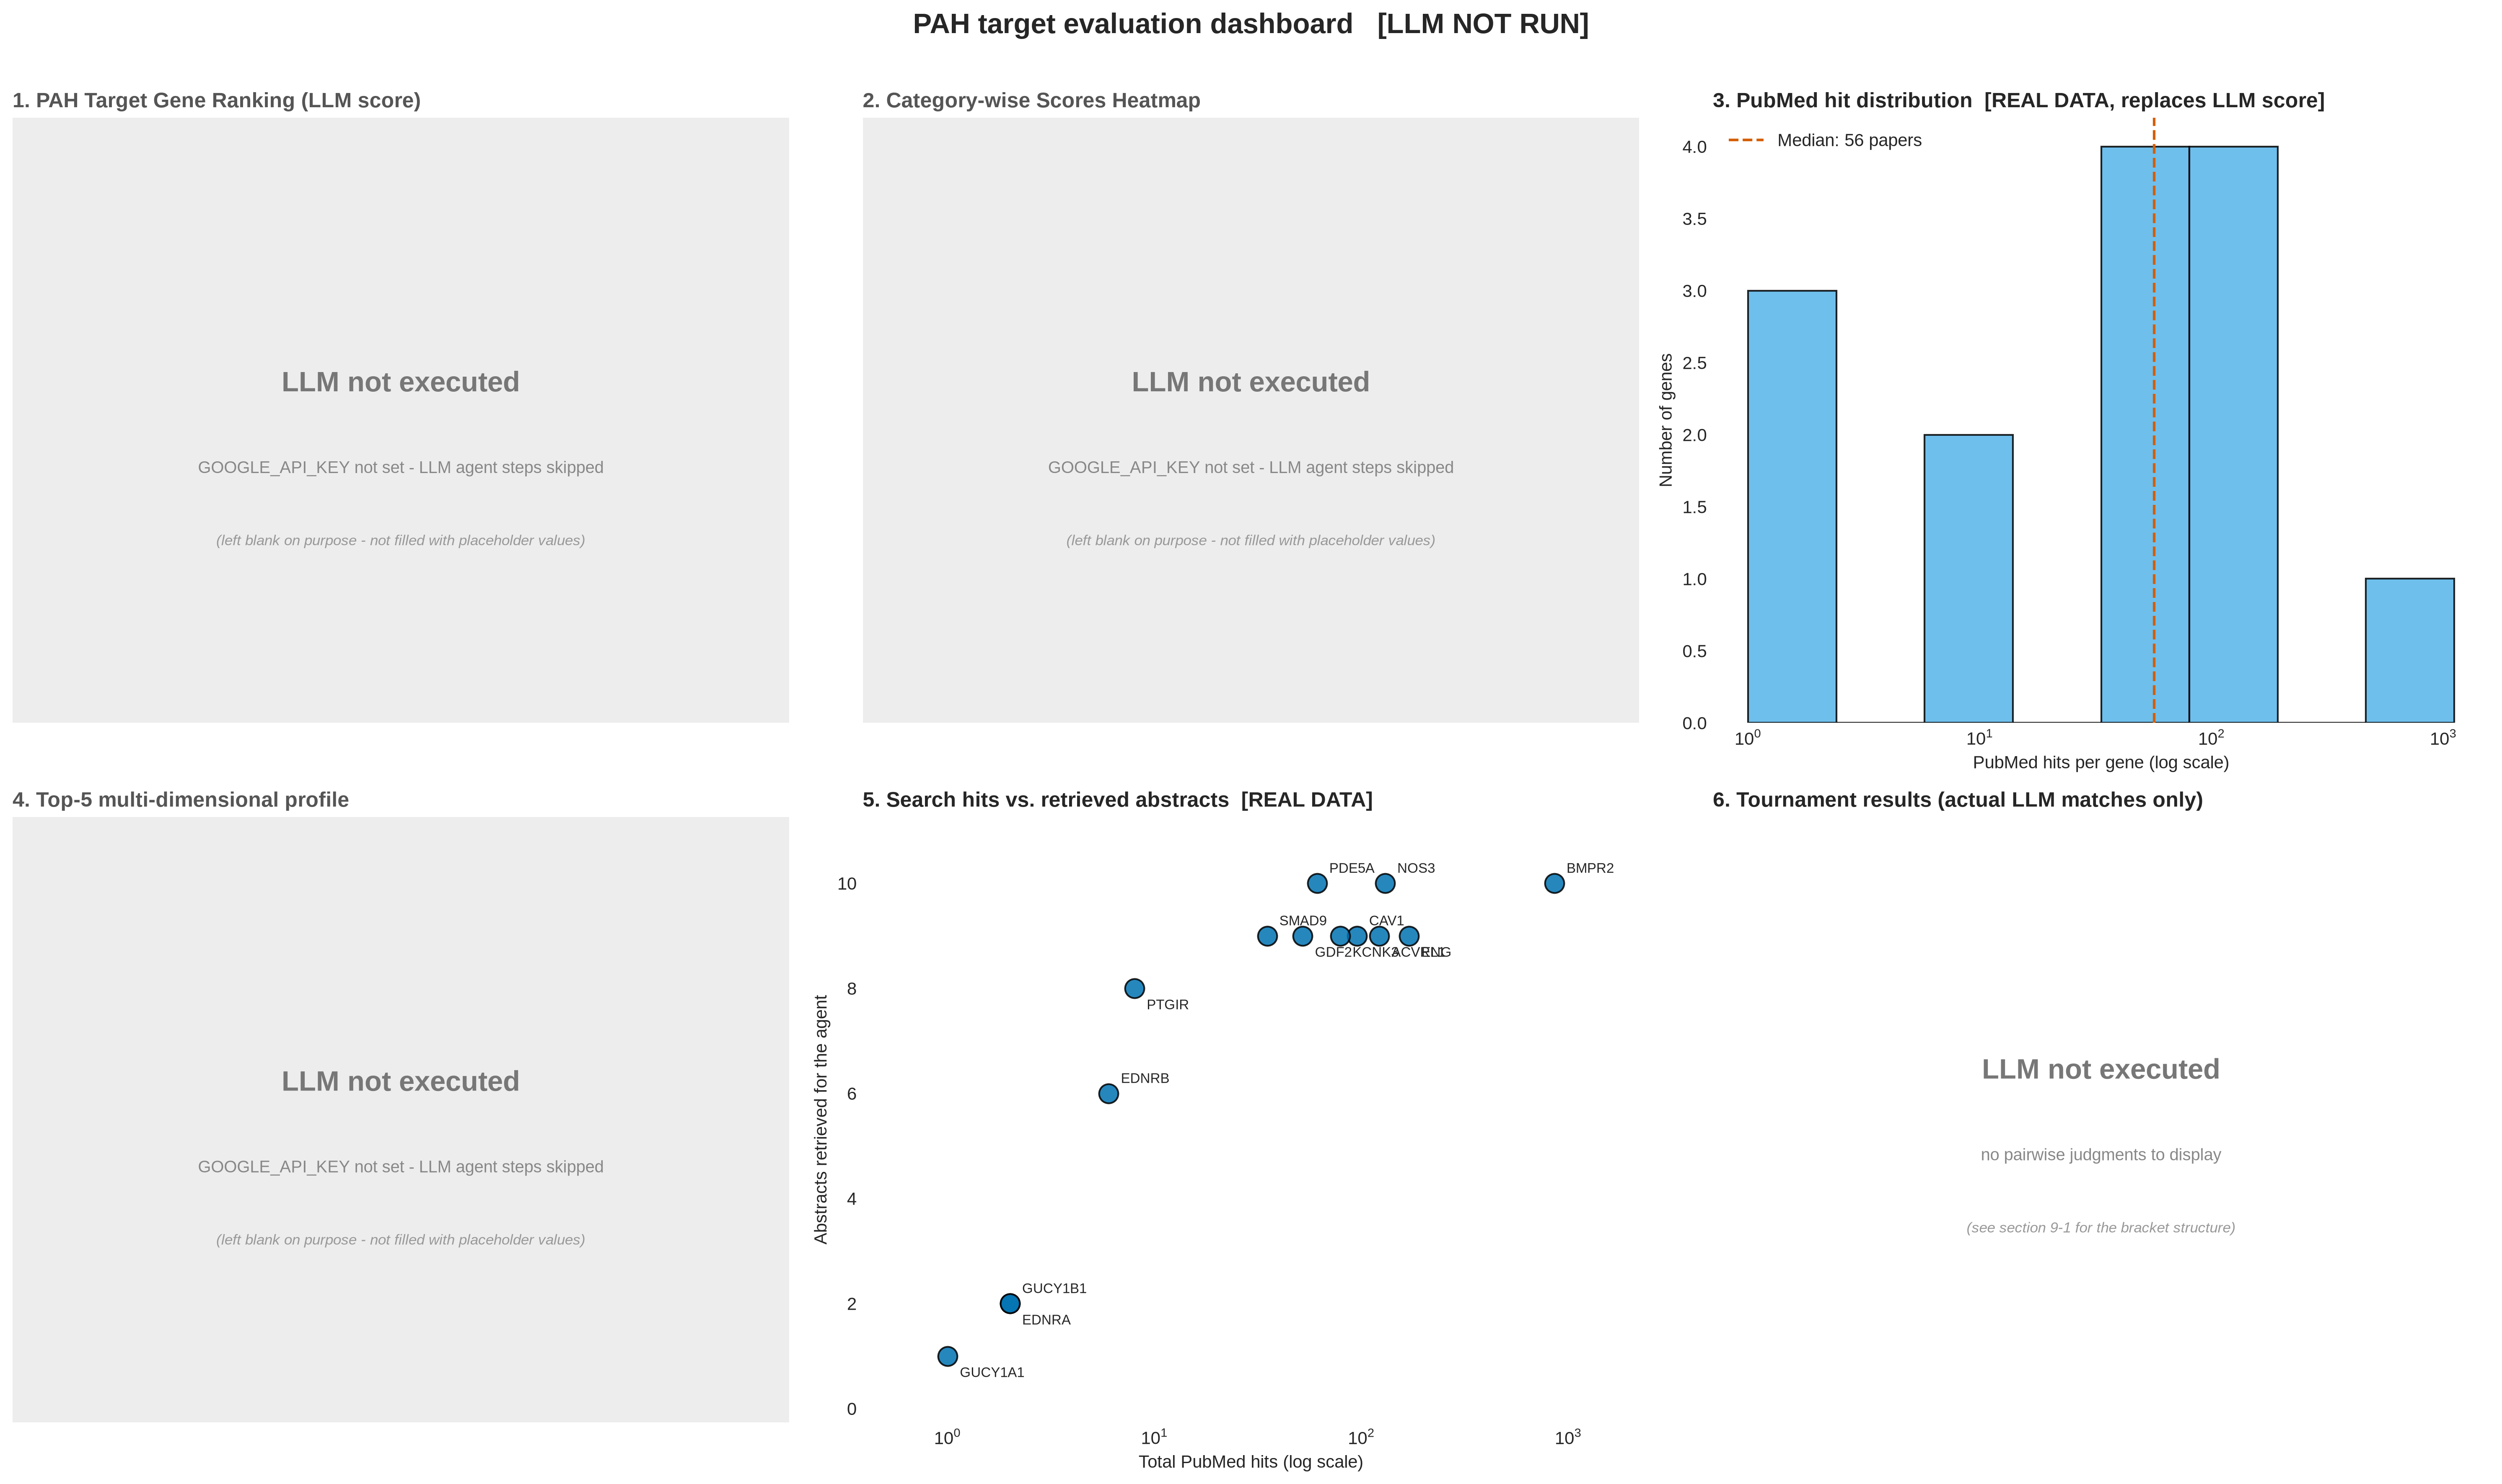

✅ 종합 시각화 완료 — 단, LLM 점수 기반 패널(1/2/4/6)은 의도적으로 비워 두었습니다.
   사유: GOOGLE_API_KEY not set - LLM agent steps skipped
   패널 3/5 는 PubMed 실데이터로 대체했습니다.


In [15]:
# 종합 시각화
#
# LLM 점수가 없는 패널은 값을 채우지 않고 "LLM not executed" 로 회색 처리합니다.
def mark_not_run(ax, title, reason=""):
    """LLM 미실행 패널: 축을 비우고 회색으로 명시 (placeholder 값 금지)."""
    ax.clear()
    ax.set_facecolor("#EDEDED")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_edgecolor("#BBBBBB")
    ax.set_title(title, fontweight="bold", loc="left", color="#555555")
    ax.text(0.5, 0.56, "LLM not executed", ha="center", va="center",
            fontsize=16, color="#777777", fontweight="bold")
    ax.text(0.5, 0.42, reason or "no GOOGLE_API_KEY -> no scores to plot",
            ha="center", va="center", fontsize=9.5, color="#888888")
    ax.text(0.5, 0.30, "(left blank on purpose - not filled with placeholder values)",
            ha="center", va="center", fontsize=8.5, style="italic", color="#999999")


SUFFIX = "" if HAS_LLM_SCORES else "   [LLM NOT RUN]"
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. 최종 점수 랭킹
ax1 = axes[0, 0]
if HAS_LLM_SCORES:
    colors = plt.cm.RdYlGn([x/10 for x in results_df["Final_Score"]])
    bars = ax1.barh(results_df["Gene"], results_df["Final_Score"], color=colors)
    ax1.set_xlabel("Final Score")
    ax1.set_title("1. PAH Target Gene Ranking (LLM score)", loc="left", fontweight="bold")
    ax1.set_xlim(0, 10)
    for i, (bar, score) in enumerate(zip(bars, results_df["Final_Score"])):
        ax1.text(score + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{score:.1f}", va="center", fontsize=8)
else:
    mark_not_run(ax1, "1. PAH Target Gene Ranking (LLM score)", LLM_SKIP_REASON)

# 2. 카테고리별 점수 히트맵
ax2 = axes[0, 1]
if HAS_LLM_SCORES:
    score_matrix = results_df[["Literature_Score", "Mechanism_Score", "Clinical_Score", "Drug_Score"]].T
    score_matrix.columns = results_df["Gene"]
    im = ax2.imshow(score_matrix.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=10)
    ax2.set_xticks(range(len(results_df)))
    ax2.set_xticklabels(results_df["Gene"], rotation=45, ha="right")
    ax2.set_yticks(range(4))
    ax2.set_yticklabels(["Literature", "Mechanism", "Clinical", "Drug"])
    ax2.set_title("2. Category-wise Scores Heatmap", loc="left", fontweight="bold")
    plt.colorbar(im, ax=ax2)
else:
    mark_not_run(ax2, "2. Category-wise Scores Heatmap", LLM_SKIP_REASON)

# 3. 스코어 분포 -> LLM 미실행 시 실데이터(PubMed 히트 수) 분포로 대체
ax3 = axes[0, 2]
if HAS_LLM_SCORES:
    ax3.hist(results_df["Final_Score"].dropna(), bins=8, alpha=0.8,
             color=OKABE["skyblue"], edgecolor="black")
    ax3.axvline(results_df["Final_Score"].mean(), color=OKABE["vermil"], linestyle="--",
                label=f"Mean: {results_df['Final_Score'].mean():.1f}")
    ax3.set_xlabel("Final score (LLM)")
    ax3.set_ylabel("Number of genes")
    ax3.set_title("3. Score Distribution", loc="left", fontweight="bold")
    ax3.legend()
else:
    _h = np.maximum(results_df["PubMed_Hits"].to_numpy(), 1)
    ax3.hist(_h, bins=np.logspace(0, np.log10(_h.max() * 1.3), 9), alpha=0.85,
             color=OKABE["skyblue"], edgecolor="black")
    ax3.set_xscale("log")
    ax3.axvline(np.median(_h), color=OKABE["vermil"], linestyle="--",
                label=f"Median: {np.median(_h):.0f} papers")
    ax3.set_xlabel("PubMed hits per gene (log scale)")
    ax3.set_ylabel("Number of genes")
    ax3.set_title("3. PubMed hit distribution  [REAL DATA, replaces LLM score]",
                  loc="left", fontweight="bold")
    ax3.legend()

# 4. 레이더 차트 (상위 5개)
ax4 = axes[1, 0]
if HAS_LLM_SCORES:
    top_5 = results_df.head(5)
    categories = ["Literature", "Mechanism", "Clinical", "Drug"]
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # 원형 완성
    for i, (_, gene_data) in enumerate(top_5.iterrows()):
        values = [gene_data["Literature_Score"], gene_data["Mechanism_Score"],
                  gene_data["Clinical_Score"], gene_data["Drug_Score"]]
        values += values[:1]
        ax4.plot(angles, values, "o-", linewidth=2, label=gene_data["Gene"])
        ax4.fill(angles, values, alpha=0.1)
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(categories)
    ax4.set_ylim(0, 10)
    ax4.set_title("4. Top 5 Genes - Multi-dimensional Analysis", loc="left", fontweight="bold")
    ax4.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax4.grid(True)
else:
    mark_not_run(ax4, "4. Top-5 multi-dimensional profile", LLM_SKIP_REASON)

# 5. 논문 수 vs 최종 점수 -> LLM 미실행 시 "검색 히트 vs 수집 초록 수"(실데이터)
ax5 = axes[1, 1]
if HAS_LLM_SCORES:
    scatter = ax5.scatter(results_df["Paper_Count"], results_df["Final_Score"],
                          c=results_df["Clinical_Score"], cmap="viridis", s=100, alpha=0.8)
    ax5.set_xlabel("Number of abstracts given to the agent")
    ax5.set_ylabel("Final score (LLM)")
    ax5.set_title("5. Literature vs Performance", loc="left", fontweight="bold")
    plt.colorbar(scatter, ax=ax5, label="Clinical Score")
    for _, row in results_df.iterrows():
        ax5.annotate(row["Gene"], (row["Paper_Count"], row["Final_Score"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=8)
else:
    ax5.scatter(np.maximum(results_df["PubMed_Hits"], 1), results_df["Paper_Count"],
                s=120, color=OKABE["blue"], edgecolor="black", alpha=0.85)
    ax5.set_xscale("log")
    ax5.set_xlabel("Total PubMed hits (log scale)")
    ax5.set_ylabel("Abstracts retrieved for the agent")
    ax5.set_title("5. Search hits vs. retrieved abstracts  [REAL DATA]",
                  loc="left", fontweight="bold")
    for _k, (_, row) in enumerate(results_df.iterrows()):
        ax5.annotate(row["Gene"], (max(row["PubMed_Hits"], 1), row["Paper_Count"]),
                     xytext=(7, 6 if _k % 2 == 0 else -12),
                     textcoords="offset points", fontsize=8)
    ax5.margins(0.14)

# 6. 실제 토너먼트 대결 결과 (np.random 으로 만든 가짜 행렬을 제거했습니다)
ax6 = axes[1, 2]
ax6.set_title("6. Tournament results (actual LLM matches only)",
              loc="left", fontweight="bold")
ax6.axis("off")
if "tournament_log" in globals() and tournament_log:
    lines = []
    for k, m in enumerate(tournament_log, 1):
        w = m["winner"] if m["winner"] else "no decision"
        lines.append(f"{k}. {m['A']} vs {m['B']}  ->  {w}")
    ax6.text(0.02, 0.95, "\n".join(lines), va="top", ha="left", fontsize=11, family="monospace")
else:
    ax6.text(0.5, 0.58, "LLM not executed" if not HAS_LLM_SCORES else "No tournament run yet",
             ha="center", va="center", fontsize=16, color="#777777", fontweight="bold")
    ax6.text(0.5, 0.44, "no pairwise judgments to display",
             ha="center", va="center", fontsize=9.5, color="#888888")
    ax6.text(0.5, 0.32, "(see section 9-1 for the bracket structure)",
             ha="center", va="center", fontsize=8.5, style="italic", color="#999999")

fig.suptitle("PAH target evaluation dashboard" + SUFFIX, fontsize=16, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

if HAS_LLM_SCORES:
    print("✅ 종합 시각화 완료!")
else:
    print("✅ 종합 시각화 완료 — 단, LLM 점수 기반 패널(1/2/4/6)은 의도적으로 비워 두었습니다.")
    print(f"   사유: {LLM_SKIP_REASON}")
    print("   패널 3/5 는 PubMed 실데이터로 대체했습니다.")

In [16]:
# 인터랙티브 시각화 (Plotly)
#
# 이 두 그림은 LLM 점수를 축으로 씁니다. 점수가 없으면(=API 키 미설정)
# 가짜 값으로 채우는 대신 Figure 를 아예 만들지 않고 이유만 출력합니다.
# (plotly 는 NaN marker size 를 거부하기도 합니다)
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if not HAS_LLM_SCORES:
    print("⏭️  [LLM 미실행] Plotly 3D / 병렬좌표 그림은 LLM 점수를 축으로 쓰므로 건너뜁니다.")
    print(f"    사유: {LLM_SKIP_REASON}")
    print("    실데이터 기반 그림은 4절(PubMed 계량 4종)과 9-1절(대진표 구조)에 있습니다.")
else:
    # 3D 스캐터 플롯
    fig = go.Figure(data=go.Scatter3d(
        x=results_df["Literature_Score"],
        y=results_df["Clinical_Score"],
        z=results_df["Drug_Score"],
        mode="markers+text",
        marker=dict(
            size=results_df["Final_Score"] * 2,
            color=results_df["Final_Score"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Final Score")
        ),
        text=results_df["Gene"],
        textposition="middle center",
        hovertemplate=
        "<b>%{text}</b><br>" +
        "Literature: %{x}<br>" +
        "Clinical: %{y}<br>" +
        "Drug: %{z}<br>" +
        "Final Score: %{marker.color}<br>" +
        "<extra></extra>"
    ))

    fig.update_layout(
        title="PAH Target Genes - 3D Performance Space (LLM scores)",
        scene=dict(
            xaxis_title="Literature Score",
            yaxis_title="Clinical Score",
            zaxis_title="Drug Score"
        ),
        width=800,
        height=600
    )
    fig.show()

    # 병렬 좌표 플롯
    fig2 = go.Figure(data=go.Parcoords(
        line=dict(color=results_df["Final_Score"],
                  colorscale="Viridis",
                  showscale=True,
                  colorbar=dict(title="Final Score")),
        dimensions=[
            dict(range=[0, 10], label="Literature", values=results_df["Literature_Score"]),
            dict(range=[0, 10], label="Mechanism", values=results_df["Mechanism_Score"]),
            dict(range=[0, 10], label="Clinical", values=results_df["Clinical_Score"]),
            dict(range=[0, 10], label="Drug", values=results_df["Drug_Score"]),
            dict(range=[0, 10], label="Final", values=results_df["Final_Score"])
        ]
    ))

    fig2.update_layout(
        title="Multi-dimensional Gene Performance Analysis (LLM scores)",
        width=900,
        height=500
    )
    fig2.show()
    print("✅ 인터랙티브 시각화 완료!")

⏭️  [LLM 미실행] Plotly 3D / 병렬좌표 그림은 LLM 점수를 축으로 쓰므로 건너뜁니다.
    사유: GOOGLE_API_KEY not set - LLM agent steps skipped
    실데이터 기반 그림은 4절(PubMed 계량 4종)과 9-1절(대진표 구조)에 있습니다.


### 9-1. 토너먼트 대진표 구조

8절의 토너먼트가 **어떤 구조로 굴러가는지**를 그림으로 봅니다.
시드(seed)는 LLM을 실행했으면 최종 점수, 실행하지 않았으면 PubMed 히트 수(실데이터)로 정해집니다.
승자 칸은 **실제 LLM 판정이 있을 때만** 채워지고, 없으면 회색 물음표로 남습니다.
빈칸을 임의의 승자로 채우지 않는 것이 이 그림의 요점입니다.

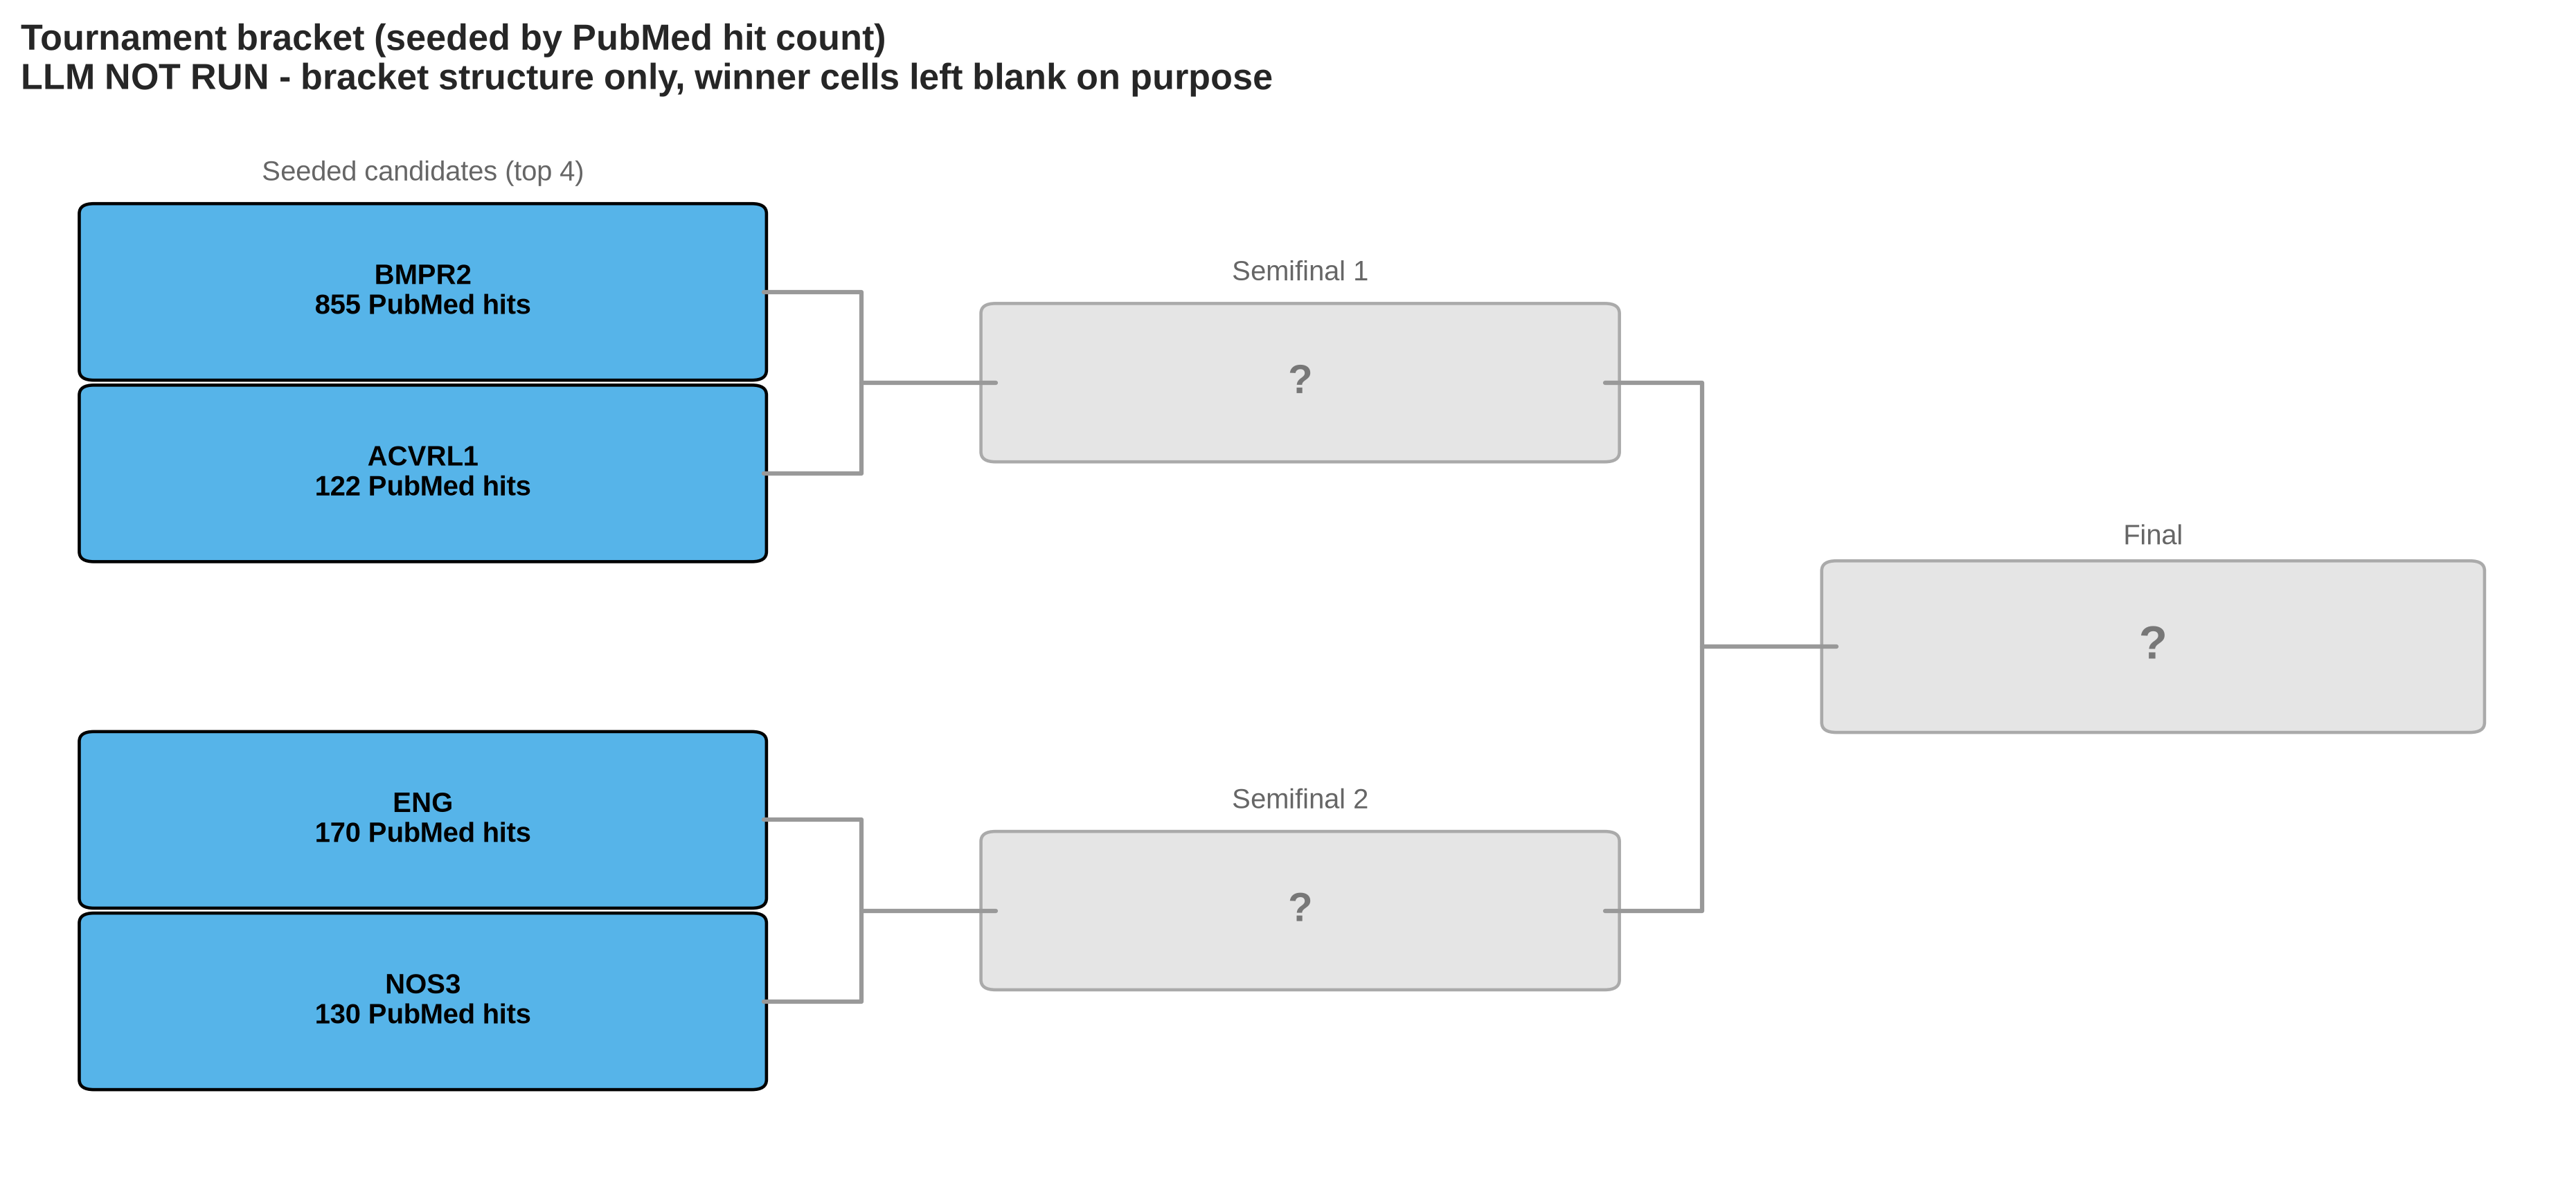

시드 기준   : PubMed hit count
기록된 대결 : 0건
준결승 승자 : ['미판정', '미판정']
우승        : 미판정 (LLM 실행 필요)


In [17]:
# --- 토너먼트 대진표 (구조는 항상, 승자는 실제 판정이 있을 때만) --------------
from matplotlib.patches import FancyBboxPatch


def _winner_of(a, b):
    for m in (tournament_log if "tournament_log" in globals() else []):
        if {m["A"], m["B"]} == {a, b}:
            return m["winner"]
    return None


seeds = top_8_genes[:4]
if len(seeds) < 4:
    print("⚠️ 시드가 4개 미만이라 대진표를 그릴 수 없습니다.")
else:
    pairs = [(seeds[0], seeds[3]), (seeds[1], seeds[2])]        # 1v4, 2v3
    sf_winners = [_winner_of(p[0][0], p[1][0]) for p in pairs]
    finalists = [w for w in sf_winners if w]
    champion = _winner_of(*finalists) if len(finalists) == 2 else None

    fig, ax = plt.subplots(figsize=(12.5, 5.8))
    ax.set_xlim(0, 10.4); ax.set_ylim(1.6, 8.0); ax.axis("off"); ax.grid(False)

    def box(x, y, text, fill, edge="black", w=2.5, h=0.8, fs=10, tc="black"):
        """대진표 그림에 둥근 사각형 칸 하나와 그 안의 글자를 그린다."""
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06",
                                    facecolor=fill, edgecolor=edge, linewidth=1.1))
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
                fontsize=fs, color=tc, fontweight="bold")

    unit_lbl = "score" if LLM_AVAILABLE else "PubMed hits"
    ys = [6.4, 5.3, 3.2, 2.1]
    flat = [pairs[0][0], pairs[0][1], pairs[1][0], pairs[1][1]]
    for (g, s, _e), y in zip(flat, ys):
        label = f"{g}\n{s:,.0f} {unit_lbl}" if s == s else f"{g}\n(no score)"
        box(0.3, y, label, OKABE["skyblue"], w=2.7, h=0.95, fs=9.5)

    sf_out_y = []
    for k, (y0, y1, wtext) in enumerate([(6.4, 5.3, sf_winners[0]),
                                         (3.2, 2.1, sf_winners[1])]):
        ymid = (y0 + y1) / 2 + 0.475
        ax.plot([3.05, 3.45, 3.45, 3.05], [y0 + 0.475, y0 + 0.475, y1 + 0.475, y1 + 0.475],
                color=OKABE["grey"], lw=1.5)
        ax.plot([3.45, 4.0], [ymid, ymid], color=OKABE["grey"], lw=1.5)
        if wtext:
            box(4.0, ymid - 0.42, wtext, OKABE["green"], w=2.5, h=0.84, fs=10.5, tc="white")
        else:
            box(4.0, ymid - 0.42, "?", "#E5E5E5", edge="#AAAAAA", w=2.5, h=0.84,
                fs=14, tc="#777777")
        ax.text(5.25, ymid + 0.62, f"Semifinal {k + 1}", fontsize=9.5, color="#666666",
                ha="center")
        sf_out_y.append(ymid)

    ax.plot([6.5, 6.9, 6.9, 6.5], [sf_out_y[0], sf_out_y[0], sf_out_y[1], sf_out_y[1]],
            color=OKABE["grey"], lw=1.5)
    fy = (sf_out_y[0] + sf_out_y[1]) / 2
    ax.plot([6.9, 7.45], [fy, fy], color=OKABE["grey"], lw=1.5)
    if champion:
        box(7.45, fy - 0.46, f"WINNER\n{champion}", OKABE["orange"], w=2.6, h=0.92, fs=11)
    else:
        box(7.45, fy - 0.46, "?", "#E5E5E5", edge="#AAAAAA", w=2.6, h=0.92,
            fs=16, tc="#777777")
    ax.text(8.75, fy + 0.62, "Final", fontsize=9.5, color="#666666", ha="center")
    ax.text(1.65, 7.55, "Seeded candidates (top 4)", fontsize=9.5, color="#666666",
            ha="center")

    status = ("Winners come from actual LLM pairwise judgments"
              if (LLM_AVAILABLE and any(sf_winners))
              else "LLM NOT RUN - bracket structure only, winner cells left blank on purpose")
    ax.set_title(f"Tournament bracket (seeded by {SEED_BY})\n{status}",
                 fontsize=12.5, fontweight="bold", loc="left")
    plt.tight_layout()
    plt.show()

    print(f"시드 기준   : {SEED_BY}")
    print(f"기록된 대결 : {len(tournament_log) if 'tournament_log' in globals() else 0}건")
    print(f"준결승 승자 : {[w or '미판정' for w in sf_winners]}")
    print(f"우승        : {champion or '미판정 (LLM 실행 필요)'}")


## 10. 최종 결과 요약 및 임상적 권고사항

In [18]:
# 최종 결과 요약 보고서 생성
print("📋 === 폐동맥고혈압(PAH) 표적 후보 유전자 종합 평가 보고서 ===")
print("")

if HAS_LLM_SCORES:
    # 상위 5개 유전자
    top_5_genes = results_df.head(5)
    print("🏆 최우선 표적 후보 (Top 5):")
    for i, (_, gene_data) in enumerate(top_5_genes.iterrows(), 1):
        print(f"\n{i}. {gene_data['Gene']} (점수: {gene_data['Final_Score']:.1f}/10)")
        print(f"   - 문헌: {gene_data['Literature_Score']:.1f}, 메커니즘: {gene_data['Mechanism_Score']:.1f}")
        print(f"   - 임상: {gene_data['Clinical_Score']:.1f}, 약물: {gene_data['Drug_Score']:.1f}")

    # 카테고리별 챔피언
    print("\n🎯 카테고리별 최우수:")
    print(f"📚 문헌 검토: {results_df.loc[results_df['Literature_Score'].idxmax(), 'Gene']} ({results_df['Literature_Score'].max():.1f}점)")
    print(f"🧬 메커니즘: {results_df.loc[results_df['Mechanism_Score'].idxmax(), 'Gene']} ({results_df['Mechanism_Score'].max():.1f}점)")
    print(f"🏥 임상적 관련성: {results_df.loc[results_df['Clinical_Score'].idxmax(), 'Gene']} ({results_df['Clinical_Score'].max():.1f}점)")
    print(f"💊 약물 개발: {results_df.loc[results_df['Drug_Score'].idxmax(), 'Gene']} ({results_df['Drug_Score'].max():.1f}점)")

    # 통계 요약
    print("\n📊 평가 통계:")
    print(f"평균 점수: {results_df['Final_Score'].mean():.2f}")
    print(f"표준편차: {results_df['Final_Score'].std():.2f}")
    print(f"최고-최저 격차: {results_df['Final_Score'].max() - results_df['Final_Score'].min():.1f}점")

    # 클러스터 분석
    high_performers = results_df[results_df["Final_Score"] >= 7.0]
    medium_performers = results_df[(results_df["Final_Score"] >= 5.0) & (results_df["Final_Score"] < 7.0)]
    low_performers = results_df[results_df["Final_Score"] < 5.0]

    print("\n🎪 성능 클러스터:")
    print(f"고성능 (7.0+): {list(high_performers['Gene'])} ({len(high_performers)}개)")
    print(f"중성능 (5.0-6.9): {list(medium_performers['Gene'])} ({len(medium_performers)}개)")
    print(f"저성능 (<5.0): {list(low_performers['Gene'])} ({len(low_performers)}개)")

    # 임상적 권고사항
    print("\n🩺 임상적 권고사항:")
    print("")
    print("1. 즉시 임상개발 추진 권장:")
    for gene in high_performers["Gene"][:3]:
        print(f"   • {gene}: 모든 평가 영역에서 우수한 성과")

    print("\n2. 추가 연구 후 개발 고려:")
    for gene in medium_performers["Gene"][:3]:
        print(f"   • {gene}: 특정 영역 강화 필요")

    print("\n3. 장기적 기초연구 필요:")
    for gene in low_performers["Gene"][:2]:
        print(f"   • {gene}: 근본적 메커니즘 규명 우선")
else:
    # 점수가 없으면 점수 기반 랭킹/권고는 생성하지 않습니다.
    # (기본값으로 채우면 그대로 허위 보고가 됩니다)
    print("⚠️  [LLM 미실행] 점수 기반 랭킹·임상 권고 보고서는 생성하지 않습니다.")
    print(f"    사유: {LLM_SKIP_REASON}")
    print("")
    print("대신 실제로 수집된 문헌 계량 결과만 보고합니다 (PubMed E-utilities, 실데이터):")
    _lit = results_df.sort_values("PubMed_Hits", ascending=False)
    for i, (_, r) in enumerate(_lit.iterrows(), 1):
        print(f"  {i:2d}. {r['Gene']:<8} PubMed hits {r['PubMed_Hits']:>7,}   "
              f"수집 초록 {r['Paper_Count']:>3}건")
    print("")
    print(f"  히트 수 합계 : {int(_lit['PubMed_Hits'].sum()):,}건")
    print(f"  중앙값       : {_lit['PubMed_Hits'].median():.0f}건")
    print("")
    print("※ 문헌이 많다는 것은 '연구가 활발하다'는 뜻이지 '좋은 표적'이라는 뜻이 아닙니다.")
    print("   표적 우선순위 판단에는 LLM 에이전트 평가(5-8절) 실행이 필요합니다.")

# 포트폴리오 권고
print("\n💼 R&D 포트폴리오 권고 (※ LLM 산출물이 아니라 강의용 고정 예시입니다):")
print("• 단기 (1-3년): PDE5A(sildenafil/tadalafil)·EDNRA(endothelin) 경로 치료제 최적화")
print("• 중기 (3-7년): GUCY1A1(sGC 자극제)·PTGIR(prostacyclin) 경로 차세대 약물 개발")
print("• 장기 (7-10년): BMPR2·ACVRL1(BMP/activin) 경로 표적 혁신 치료법")

print("\n" + "="*60)
if HAS_LLM_SCORES:
    print("✅ LLM Co-scientist 기반 표적 평가 완료!")
    print("이 결과는 AI 분석이므로 전문가 검토 후 활용하시기 바랍니다.")
else:
    print("✅ 파이프라인 실행 완료 (LLM 구간 미실행).")
    print("   실데이터 산출물: 4절 문헌 계량 그림 4종 + 9-1절 대진표 구조")
print("="*60)

📋 === 폐동맥고혈압(PAH) 표적 후보 유전자 종합 평가 보고서 ===

⚠️  [LLM 미실행] 점수 기반 랭킹·임상 권고 보고서는 생성하지 않습니다.
    사유: GOOGLE_API_KEY not set - LLM agent steps skipped

대신 실제로 수집된 문헌 계량 결과만 보고합니다 (PubMed E-utilities, 실데이터):
   1. BMPR2    PubMed hits     855   수집 초록  10건
   2. ENG      PubMed hits     170   수집 초록   9건
   3. NOS3     PubMed hits     130   수집 초록  10건
   4. ACVRL1   PubMed hits     122   수집 초록   9건
   5. CAV1     PubMed hits      95   수집 초록   9건
   6. KCNK3    PubMed hits      79   수집 초록   9건
   7. PDE5A    PubMed hits      61   수집 초록  10건
   8. GDF2     PubMed hits      52   수집 초록   9건
   9. SMAD9    PubMed hits      35   수집 초록   9건
  10. PTGIR    PubMed hits       8   수집 초록   8건
  11. EDNRB    PubMed hits       6   수집 초록   6건
  12. EDNRA    PubMed hits       2   수집 초록   2건
  13. GUCY1B1  PubMed hits       2   수집 초록   2건
  14. GUCY1A1  PubMed hits       1   수집 초록   1건

  히트 수 합계 : 1,618건
  중앙값       : 56건

※ 문헌이 많다는 것은 '연구가 활발하다'는 뜻이지 '좋은 표적'이라는 뜻이 아닙니다.
   표적 우선순위 판단에는 LLM 에이전트 평가(5-8절) 실행이 필

## 11. 참고문헌


> 2026-09 기준으로 DOI/arXiv ID를 직접 조회해 확인한 항목만 남겼습니다.
> (이전 버전에 있던 "Wang et al. (2024). Multi-Agent Framework for Scientific Discovery,
> *Nature Machine Intelligence* 6, 112-125" 는 실재를 확인할 수 없어 삭제했습니다.)

1. **LangChain Documentation**. https://python.langchain.com/
2. **LangGraph Documentation**. https://langchain-ai.github.io/langgraph/
3. **Google Gemini API** (Google AI for Developers). https://ai.google.dev/
4. **Boiko, D. A., MacKnight, R., Kline, B., & Gomes, G.** (2023).
   *Autonomous chemical research with large language models.* **Nature**, 624, 570-578.
   doi:10.1038/s41586-023-06792-0
5. **NCBI E-utilities API**. https://www.ncbi.nlm.nih.gov/books/NBK25501/
6. **Bai, Y., Kadavath, S., Kundu, S., Askell, A., et al.** (2022).
   *Constitutional AI: Harmlessness from AI Feedback.* arXiv:2212.08073
7. **Park, J. S., O'Brien, J. C., Cai, C. J., Morris, M. R., et al.** (2023).
   *Generative Agents: Interactive Simulacra of Human Behavior.* UIST '23. arXiv:2304.03442
8. **Gottweis, J., Weng, W.-H., Daryin, A., Tu, T., et al.** (2025).
   *Accelerating scientific discovery with Co-Scientist.* arXiv:2502.18864
   — 이 노트북이 흉내 내는 "AI co-scientist" 다중 에이전트 구조의 원형입니다.

### 11-1. 유용한 리소스


- **Google AI Studio**: https://makersuite.google.com/
- **PubMed**: https://pubmed.ncbi.nlm.nih.gov/
- **LangChain Hub**: https://smith.langchain.com/hub
- **OpenAI API**: https://platform.openai.com/
- **Anthropic Claude**: https://console.anthropic.com/


## 12. 한계와 주의

- **LLM 점수는 근거가 아니라 의견이다.** 다섯 에이전트가 매긴 0~10점은 모델이 읽은 초록에서
  뽑아낸 인상이며, 실험 데이터나 임상 결과로 검증된 값이 아니다. 표적 선정의 근거로 쓸 수 없다.
- **문헌 히트 수는 하한값이다.** 검색이 유전자 심볼 기준이라, 심볼 대신 단백질명·약물군으로만
  쓰인 논문(예: `EDNRA` 대신 "endothelin receptor A")은 통째로 빠진다. 심볼 관행이 다른
  유전자끼리의 절대 비교는 성립하지 않는다.
- **논문이 많다는 것이 좋은 표적이라는 뜻은 아니다.** 문헌량은 관심도의 대리 지표일 뿐이고,
  오히려 "이미 붐비는 영역"이라는 신호이기도 하다.
- **결과가 실행마다 달라진다.** Gemini 응답은 결정론적이지 않고, 사용 가능한 모델도 런타임에
  조회해 고르므로 점수와 순위가 재현되지 않는다. 토너먼트 결과도 함께 흔들린다.
- **API 키가 없으면 절반만 돈다.** 4절 문헌 계량 그림 4종과 9-1절 대진표 구조는 실데이터로
  항상 나오지만, LLM 점수가 필요한 칸은 임의값으로 채우지 않고 비워 둔다.
- **10절의 R&D 포트폴리오 권고는 LLM 산출물이 아니다.** 강의용으로 고정해 둔 예시 문구다.

### 12-1. 윤리적 고려사항


- LLM 기반 분석 결과는 참고용이며, 실제 임상 결정에는 전문가 검토 필수
- API 사용량 제한 및 비용 고려
- 논문 저작권 및 공정 사용 원칙 준수
- 환자 데이터 사용 시 개인정보보호 규정 준수


## 13. 다음 실습

6일차의 다른 노트북으로 이어진다.

- [`t050_simple-local-rag.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t050_simple-local-rag.ipynb)
  — 여기서는 초록을 그대로 프롬프트에 넣었지만, 그쪽은 **검색 품질 자체를 어떻게 만드는지**를
  PDF 수집부터 임베딩·재현성까지 직접 조립한다.
- [`t042_molt5.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t042_molt5.ipynb)
  — 표적이 정해진 다음 단계. 자연어 설명과 분자 구조(SMILES)를 오가는 화학 언어모델.
- [`t110_esm2_peptide_optimization_tutorial.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t110_esm2_peptide_optimization_tutorial.ipynb)
  — 단백질 표적에 붙을 펩타이드를 단백질 언어모델로 설계하는 실습.

---

**라이선스**: MIT License  
**작성**: LLM Co-scientist Team (2025-01 초판) · 2026-09 강의용 개정
